In [4]:
#using Plots
using PyPlot
using DelimitedFiles
const plt = PyPlot
# Set rcParams in Julia
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text

In [5]:
#ion()  # Turn on the interactive mode which might help in Jupyter

## Load data


### Just one data

In [17]:
#-------- General parameters-------
name = "test11"#A_U_0.0+Omega_3.65+zs_0.0+js_0.02"
#"test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"#"test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.02"#"test:U_0.0+Omega_1.52+zs_0.1+js_0.1"#"testp1"#"testp" #"test"#
hbar = 0.658211928e0
nx=2
n=nx*1
t_end = 50#4000#600
t_step = 0.1
ts = 0.1:t_step:t_end

#0.1,0.2---0.8,0.9 # change
#0.0,0.3,0.4,0.5,0.6,0.7,1.0 # same

0.1:0.1:50.0

In [18]:
# Variable definition
name1 = name#"test1"  # This is the active filename, uncomment others as needed
# Path definition (ensure 'path' is defined or replace it with the actual path)
path = "./data"  # Make sure to define or replace this with the correct path
#--------------------------------------------------------- Data from the TDNEGF code
# Loading data from text files
cspins_f = readdlm(joinpath(path, "cspins_$(name1)_jl.txt")) ;
sneq_f = readdlm(joinpath(path, "sneq_$(name1)_jl.txt"))
#seq_f = readdlm(joinpath(path, "seq_$(name1)_jl.txt"))
sc_f = readdlm(joinpath(path, "sc_$(name1)_jl.txt"))
cc_f = readdlm(joinpath(path, "cc_$(name1)_jl.txt"))
# # # #---------------------------------------------------------- Data for the density and the bond current
#bcurr1_f = readdlm(joinpath(path, "bcurr1_$(name1)_jl.txt"))
#bcurr2_f = readdlm(joinpath(path, "bcurr2_$(name1)_jl.txt"))
#cden_f = readdlm(joinpath(path, "cden_$(name1)_jl.txt"));
#chi_f = readdlm(joinpath(path, "chi_nd_$(name1)_jl.txt"))

400×1 Matrix{Float64}:
  1.934605814473231
  1.934605814473231
  3.579775379648444
  3.579775379648444
  4.744903495318465
  4.744648978989811
  5.346997706112598
  5.345793892434578
  5.420272835157973
  5.4171226934068235
  5.0974179936308435
  5.091779172567779
  4.566590614950039
  ⋮
  0.010561270711277243
  0.008757375694135592
 -0.2985028100806886
  0.3209350987554202
 -0.5689446568499504
  0.5917947107633427
 -0.765140950051955
  0.7856161350391491
 -0.8609179451607516
  0.8770492619833953
 -0.8429564233188307
  0.8542323118521336

In [49]:
#seq_f

In [19]:
# sneq_f
# seq_f

t_eff_sn = Int(length(sneq_f[1:n:end,1]))

t_eff_cc = Int(length(cc_f[1:2:end])) # Int(t_end/t_step)
t_eff_sc = Int(length(sc_f[1:3:end,1]))
t_eff_cs = Int(length(cspins_f[1:Int(ceil(n/2)):end,1]))
#t_eff_cd = Int(length(cden_f[1:n:end]));
#t_eff_chi =Int(length(chi_f))
#t_eff_se = Int(length(seq_f[1:n:end,1]))
#t_eff_bc1 = Int(length(bcurr1_f[1:4:end,1]))
#t_eff_bc2 = Int(length(bcurr2_f[1:4:end,1]))

#cden_f[i:n:end]

800

In [20]:
# n=40 ### Number of effective sites in the TDNEGF code 
# t_end = 100
# t_step = 0.1
# ts = 0.1:t_step:t_end
########################
sneq_ta1x = zeros(Float64,t_eff_sn, n,3 )
#seq_ta1x = zeros(Float64,t_eff_se, n,3 )
cspins_tax = zeros(Float64,t_eff_cs, Int(n//2),3 )
cc_αt = zeros(Float64,2,t_eff_cc)
sc_αxt = zeros(Float64,2,3,t_eff_sc)
#cden_ta1 = zeros(Float64,t_eff_cd, n)

# bcc1_ta1 = zeros(Float64,t_eff_bc1, Int(n//4)-1)
# bscx1_ta1  = zeros(Float64,t_eff_bc1, Int(n//4)-1)
# bscy1_ta1  = zeros(Float64,t_eff_bc1, Int(n//4)-1)
# bscz1_ta1  = zeros(Float64,t_eff_bc1, Int(n//4)-1)

# bcc2_ta1 = zeros(Float64,t_eff_bc2, Int(n//4)-1)
# bscx2_ta1  = zeros(Float64,t_eff_bc2, Int(n//4)-1)
# bscy2_ta1  = zeros(Float64,t_eff_bc2, Int(n//4)-1)
# bscz2_ta1  = zeros(Float64,t_eff_bc2, Int(n//4)-1)
#######################
#-------------- Charge current -------------------
cc_αt[1,:] = cc_f[1:2:end] # Left Charge current
cc_αt[2,:] = cc_f[2:2:end] # Right Charge current
#-------------- Spin current -------------------
#### X component
sc_αxt[1,1,:] = sc_f[1:3:end,1] # Left spin current
sc_αxt[2,1,:] = sc_f[1:3:end,2] # RIght spin current
## Y component
sc_αxt[1,2,:] = sc_f[2:3:end,1] 
sc_αxt[2,2,:] = sc_f[2:3:end,2]
### Z component
sc_αxt[1,3,:] = sc_f[3:3:end,1]
sc_αxt[2,3,:] = sc_f[3:3:end,2]

# for i in range(1,n)
#     ##### Noneq spin density 
#     #sneq_ta1x[:,i,:] = sneq_f[i:n:end,:]
#     ##### Eq. spin density 
#     #seq_ta1x[:,i,:] = seq_f[i:n:end,:]
#     # ##### Charge density  
#     #cden_ta1[:,i] = cden_f[i:n:end]
#     ##### Charge Spin density  
# end
#### Classical spin density
# for i in range(1,Int(n//2) ) 
#     cspins_tax[:,i,:] = cspins_f[i:Int(n//2):end,:]
# end

# ##### Local current 
# for i in range(1,Int(n//4)-1 ) 
#     bcc1_ta1[:,i] = bcurr1_f[1:4:end,i]
#     bscx1_ta1[:,i] = bcurr1_f[2:4:end,i]
#     bscy1_ta1[:,i] = bcurr1_f[3:4:end,i]
#     bscz1_ta1[:,i] = bcurr1_f[4:4:end,i]
    
#     bcc2_ta1[:,i] = bcurr2_f[1:4:end,i]
#     bscx2_ta1[:,i] = bcurr2_f[2:4:end,i]
#     bscy2_ta1[:,i] = bcurr2_f[3:4:end,i]
#     bscz2_ta1[:,i] = bcurr2_f[4:4:end,i]
# end

ts_sn=0.1:0.1:t_eff_sn*t_step
ts_cc=0.1:0.1:t_eff_cc*t_step
ts_sc=0.1:0.1:t_eff_sc*t_step
ts_cs=0.1:0.1:t_eff_cs*t_step
#ts_cd=0.1:0.1:t_eff_cd*t_step ;
#ts_se=0.1:0.1:t_eff_se*t_step
#ts_chi=0.1:0.1:t_eff_chi*t_step
# ts_bc1=0.1:0.1:t_eff_bc1*t_step
# ts_bc2=0.1:0.1:t_eff_bc2*t_step

0.1:0.1:80.0

### Many data

In [5]:
#cspins_f


# Initialize an empty dictionary to store the data
#data = Dict()

# Define the path where the files are stored
path = "./data_kohn"
#path = "./TDNEGF_exciton/data"

# sneq_ta1x = zeros(Float64,Int(t_end/t_step), n,3 )
# seq_ta1x = zeros(Float64,Int(t_end/t_step), n,3 )
# cspins_tax = zeros(Float64,Int(t_end/t_step), Int(n//2),3 )
# cc_αt = zeros(Float64,2,Int(t_end/t_step))
# sc_αxt = zeros(Float64,2,3,Int(t_end/t_step))
# cden_ta1 = zeros(Float64,Int(t_end/t_step), n)

# bcc1_ta1 = zeros(Float64,Int(t_end/t_step), Int(n//4)-1)
# bscx1_ta1  = zeros(Float64,Int(t_end/t_step), Int(n//4)-1)
# bscy1_ta1  = zeros(Float64,Int(t_end/t_step), Int(n//4)-1)
# bscz1_ta1  = zeros(Float64,Int(t_end/t_step), Int(n//4)-1)

# bcc2_ta1 = zeros(Float64,Int(t_end/t_step), Int(n//4)-1)
# bscx2_ta1  = zeros(Float64,Int(t_end/t_step), Int(n//4)-1)
# bscy2_ta1  = zeros(Float64,Int(t_end/t_step), Int(n//4)-1)
# bscz2_ta1  = zeros(Float64,Int(t_end/t_step), Int(n//4)-1)
#testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"
# Names corresponding to the file identifiers
#names = ["NiPt3_soc", "Ni2"]
#names2 = ["pumping_norm_soc", "pumping_norm_nosoc"]
U0s = 0.5#[0.0,0.1,0.2]#[0.0,0.1,0.2]#[0.0,0.1,0.2]#[0.01,0.05,0.1,0.15]#0.2#[0.0,0.2]#[0.0,0.4,1.0]#0.0:0.2:1.0#[0.0,0.4,1.0]#0.0:0.2:1.0
ws = 3.6#2.2:0.2:4.0#3.65#[2.43,3.04,3.65,4.56,6.08]#3.65#[2.43,3.04,3.65,4.56,6.08]#[1.6,2.4,3.6]
zs= 0.1#0.1#0.1#[0.1,0.2,0.3]#0.1#[0.1,0.2,0.3]#0.1#[0.0,0.02]
js=[0.0,0.01,0.02,0.001]#0.005,0.008] 
#[0.0,0.001,0.01,0.02]#[0.0,0.02]#[0.0,0.01,0.02]#[0.0,0.01,0.02]#0.01#0.02#[0.0,0.02,0.05]#[0.0,0.02,0.05,0.08]#[0.1,0.2,0.3]#[0.0,0.02]#[0.05,0.08]#[0.1,0.2,0.3]#[0.0,0.02]

#test:U_1.0+Omega_1.2+zs_0.01
# Loop through the names and load data
for i1 in 1:length(U0s), i2 in 1:length(ws) ,i3 in 1:length(zs), i4 in 1:length(js)
    #println(i1, i2, i3)
    
    #println(U0s[i1],ws[i2],zs[i3])
    name = "res_ns_mtp_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=4))"
    #"resdef_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=4))"
    #"testA_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=2))"
    #"res_mt_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=2))"
    #"testA_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=2))"
    #"res_mt_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=2))"
    #"testA_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=2))"
    #"res_mt_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=2))"
    println(name)
    #name = names[j]
    #name2 = names2[j]
    data["cspins_f_$name"] = readdlm(joinpath(path, "cspins_$(name)_jl.txt"))
    # data["sneq_f_$name"] = readdlm(joinpath(path, "sneq_$(name)_jl.txt"))
    # data["seq_f_$name"] = readdlm(joinpath(path, "seq_$(name)_jl.txt"))
    # data["sc_f_$name"] = readdlm(joinpath(path, "sc_$(name)_jl.txt"))
    data["cc_f_$name"] = readdlm(joinpath(path, "cc_$(name)_jl.txt"))
    data["cden_f_$name"] = readdlm(joinpath(path, "cden_$(name)_jl.txt"))
    
    # Loading data from text files
    cspins_f = readdlm(joinpath(path, "cspins_$(name)_jl.txt"))
    # sneq_f = readdlm(joinpath(path, "sneq_$(name)_jl.txt"))
    # seq_f = readdlm(joinpath(path, "seq_$(name)_jl.txt"))
    # sc_f = readdlm(joinpath(path, "sc_$(name)_jl.txt"))
    cc_f = readdlm(joinpath(path, "cc_$(name)_jl.txt"))
    #---------------------------------------------------------- Data for the density and the bond current
    bcurr1_f = readdlm(joinpath(path, "bcurr1_$(name)_jl.txt"))
    bcurr2_f = readdlm(joinpath(path, "bcurr2_$(name)_jl.txt"))
    cden_f = readdlm(joinpath(path, "cden_$(name)_jl.txt"));
    chi_f = readdlm(joinpath(path, "chi_nd_$(name)_jl.txt"));


    ########################################
    t_eff_chi =Int(length(chi_f))
    # t_eff_sn = Int(length(sneq_f[1:n:end,1]))
    # t_eff_se = Int(length(seq_f[1:n:end,1]))
    #t_eff_sc = Int(length(sc_f[1:3:end,1]))
    t_eff_cc = Int(length(cc_f[1:2:end])) # Int(t_end/t_step)
    t_eff_cs = Int(length(cspins_f[1:Int(n//2):end,1]))
    t_eff_cd = Int(length(cden_f[1:n:end]))
    t_eff_bc1 = Int(length(bcurr1_f[1:4:end,1]))
    t_eff_bc2 = Int(length(bcurr2_f[1:4:end,1]))

    ts_chi=0.1:0.1:t_eff_chi*t_step
    # ts_sn=0.1:0.1:t_eff_sn*t_step
    # ts_se=0.1:0.1:t_eff_se*t_step
    # ts_sc=0.1:0.1:t_eff_sc*t_step
    ts_cc=0.1:0.1:t_eff_cc*t_step
    ts_cs=0.1:0.1:t_eff_cs*t_step
    ts_cd=0.1:0.1:t_eff_cd*t_step
    ts_bc1=0.1:0.1:t_eff_bc1*t_step
    ts_bc2=0.1:0.1:t_eff_bc2*t_step

    # sneq_ta1x = zeros(Float64,t_eff_sn, n,3 )
    # seq_ta1x = zeros(Float64,t_eff_se, n,3 )
    # sc_αxt = zeros(Float64,2,3,t_eff_sc)
    cspins_tax = zeros(Float64,t_eff_cs, Int(n//2),3 )
    cc_αt = zeros(Float64,2,t_eff_cc)

    cden_ta1 = zeros(Float64,t_eff_cd, n)
    
    bcc1_ta1 = zeros(Float64,t_eff_bc1, Int(n//4)-1)
    bscx1_ta1  = zeros(Float64,t_eff_bc1, Int(n//4)-1)
    bscy1_ta1  = zeros(Float64,t_eff_bc1, Int(n//4)-1)
    bscz1_ta1  = zeros(Float64,t_eff_bc1, Int(n//4)-1)
    
    bcc2_ta1 = zeros(Float64,t_eff_bc2, Int(n//4)-1)
    bscx2_ta1  = zeros(Float64,t_eff_bc2, Int(n//4)-1)
    bscy2_ta1  = zeros(Float64,t_eff_bc2, Int(n//4)-1)
    bscz2_ta1  = zeros(Float64,t_eff_bc2, Int(n//4)-1)
    

    #######################
    #-------------- Charge current -------------------
    cc_αt[1,:] = cc_f[1:2:end] # Left Charge current
    cc_αt[2,:] = cc_f[2:2:end] # Right Charge current
    #-------------- Spin current -------------------
    #### X component
    # sc_αxt[1,1,:] = sc_f[1:3:end,1] # Left spin current
    # sc_αxt[2,1,:] = sc_f[1:3:end,2] # RIght spin current
    # ### Y component
    # sc_αxt[1,2,:] = sc_f[2:3:end,1] 
    # sc_αxt[2,2,:] = sc_f[2:3:end,2]
    # ### Z component
    # sc_αxt[1,3,:] = sc_f[3:3:end,1]
    # sc_αxt[2,3,:] = sc_f[3:3:end,2]

    for i in range(1,n)
        ##### Noneq spin density 
        #sneq_ta1x[:,i,:] = sneq_f[i:n:end,:]
        ##### Eq. spin density 
        #seq_ta1x[:,i,:] = seq_f[i:n:end,:]
        ##### Charge density  
        cden_ta1[:,i] = cden_f[i:n:end]
        ##### Charge Spin density  
    end
    ##### Classical spin density
    for i in range(1,Int(n//2) ) 
        cspins_tax[:,i,:] = cspins_f[i:Int(n//2):end,:]
    end

    ##### Local current 
    for i in range(1,Int(n//4)-1 ) 
        bcc1_ta1[:,i] = bcurr1_f[1:4:end,i]
        bscx1_ta1[:,i] = bcurr1_f[2:4:end,i]
        bscy1_ta1[:,i] = bcurr1_f[3:4:end,i]
        bscz1_ta1[:,i] = bcurr1_f[4:4:end,i]

        bcc2_ta1[:,i] = bcurr2_f[1:4:end,i]
        bscx2_ta1[:,i] = bcurr2_f[2:4:end,i]
        bscy2_ta1[:,i] = bcurr2_f[3:4:end,i]
        bscz2_ta1[:,i] = bcurr2_f[4:4:end,i]
    end
    #println(1)
    data["cspins_tax_$name"] = cspins_tax
    #data["sneq_ta1x_$name"] = sneq_ta1x
    #data["seq_ta1x_$name"] = seq_ta1x
     data["cc_αt_$name"] = cc_αt
     #data["sc_αxt_$name"] = sc_αxt
    data["cden_ta1_$name"] = cden_ta1
     data["bcc1_ta1_$name"] = bcc1_ta1
     data["bscx1_ta1_$name"] = bscx1_ta1#bcc1_ta1#sc_αxt
     data["bscy1_ta1_$name"] = bscy1_ta1
     data["bscz1_ta1_$name"] = bscz1_ta1

     data["bcc2_ta1_$name"] = bcc2_ta1
     data["bscx2_ta1_$name"] = bscx2_ta1#bcc1_ta1#sc_αxt
     data["bscy2_ta1_$name"] = bscy2_ta1
     data["bscz2_ta1_$name"] = bscz2_ta1

    data["chi_nd_t_$name"] = chi_f#bscz2_ta1
    
    data["ts_chi_$name"] =  ts_chi
    
    #data["ts_sn_$name"] = ts_sn
    #data["ts_se_$name"] = ts_se
    data["ts_cc_$name"] = ts_cc
    #data["ts_sc_$name"] = ts_sc
    data["ts_cs_$name"] = ts_cs
    data["ts_cd_$name"] = ts_cd
    data["ts_bc1_$name"] = ts_bc1
    data["ts_bc2_$name"] = ts_bc2
end

res_ns_mtp_U_0.5+Omega_3.6+zs_0.1+js_0.0
res_ns_mtp_U_0.5+Omega_3.6+zs_0.1+js_0.01
res_ns_mtp_U_0.5+Omega_3.6+zs_0.1+js_0.02
res_ns_mtp_U_0.5+Omega_3.6+zs_0.1+js_0.001


# Plot normal

## Classical spins

sys:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


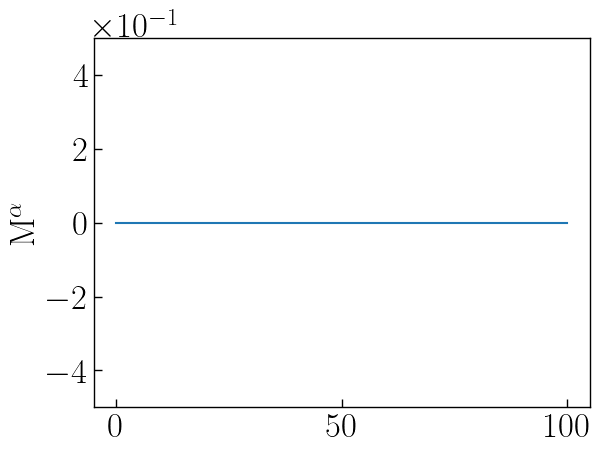

In [52]:
fig,axs = plt.subplots(1,1)
fs=25
site = 2
axs.plot(ts_cs,cspins_tax[:,site,2])
#axs.plot(ts_cs,cspins_tax[:,site+2,3])
axs.set_ylabel(L"$\mathrm{M^{\alpha}}$", fontsize = fs)
#axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.set_ylim([-5e-1,+5e-1])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([350,800])
#axs.set_xlim([950,1050])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.show()
#axs.set_xlim(1800,2100)

## Current

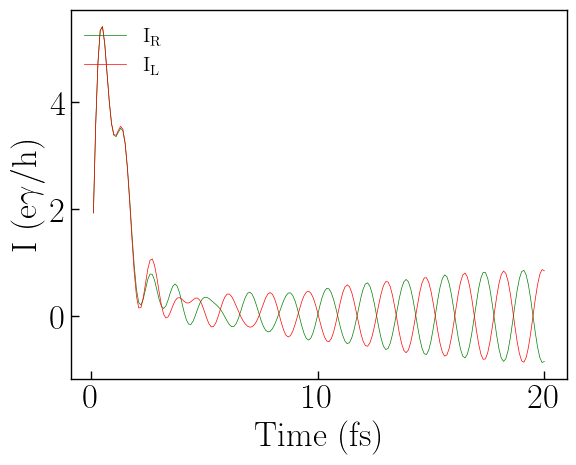

In [21]:
fig,axs = plt.subplots(1,1)
fs=25

axs.plot(ts_cc,cc_αt[1,:],color= "green",lw = 0.5,label = raw"$\mathrm{I_R}$")
axs.plot(ts_cc,cc_αt[2,:],color= "red",lw = 0.5,label = raw"$\mathrm{I_L}$")
axs.set_ylabel(L"$\mathrm{I\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.show()

#plt.tight_layout()


In [57]:
#data.keys

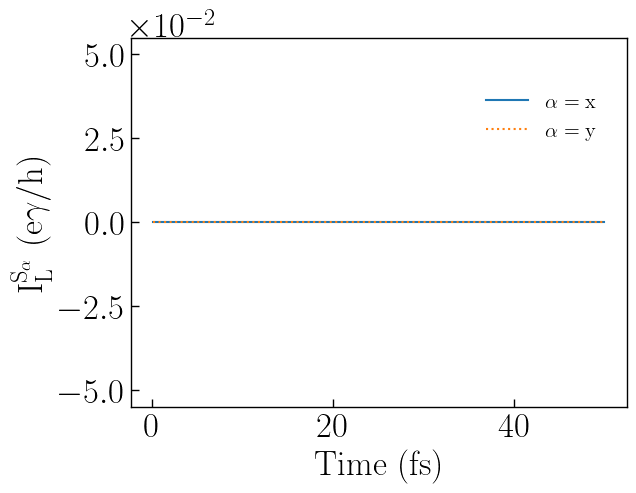

PyObject <matplotlib.legend.Legend object at 0x7f9b17c07ef0>

In [61]:
fig,axs = plt.subplots(1,1)
axs.plot(ts_sc,sc_αxt[1,1,:], label = raw"$\mathrm{\alpha = x}$")
axs.plot(ts_sc,sc_αxt[1,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
#axs.plot(ts_sc,sc_αxt[1,3,:], label = raw"$\mathrm{\alpha = z}$")
axs.set_ylabel(raw"$\mathrm{I^{S_{\alpha}}_L\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))


## Spin densities

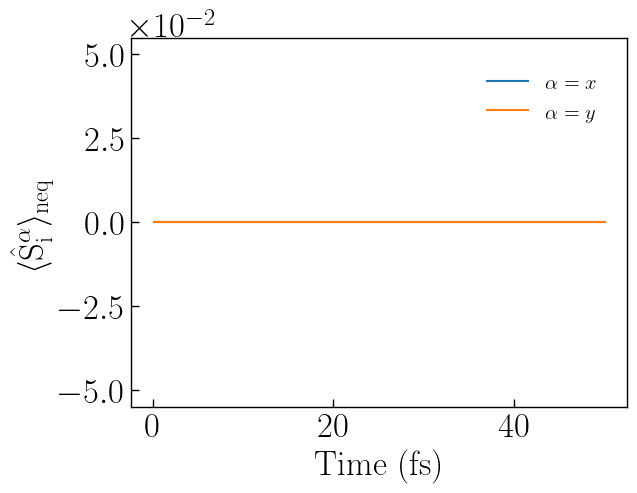

PyObject <matplotlib.legend.Legend object at 0x7f9b17816ea0>

In [66]:
fig,axs = plt.subplots(1,1)
fs=25
site = 1
mag = sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2
axs.plot(ts_sn,sneq_ta1x[:,site,1],label = raw"$\alpha=x$")
axs.plot(ts_sn,sneq_ta1x[:,site,2],label = raw"$\alpha=y$")
axs.set_ylabel(raw"$\langle\mathrm{\hat{S}^{\alpha}_{i}}\rangle_{\mathrm{neq}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.75))

In [68]:
# fig,axs = plt.subplots(1,1)
# #plt.plot(data[f"cspins_f_{name1}"][:,0],data[f"cspins_f_{name1}"][:,13])
# site = 1
# axs.plot(ts_se,seq_ta1x[:,site,1],label = raw"$\alpha=x$")
# #axs.plot(ts_se,seq_ta1x[:,site+1,1],label = raw"$\alpha=x$")
# # axs.plot(ts_se,seq_ta1x[:,site,2],label = raw"$\alpha=y$")
# # axs.plot(ts_se,seq_ta1x[:,site,3],label = raw"$\alpha=z$")
# axs.set_ylabel(raw"$\langle\mathrm{\hat{S}^{\alpha}_{i}}\rangle_{\mathrm{eq}}$", fontsize = fs)
# axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
# axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
# axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
# axs.yaxis.offsetText.set_fontsize(fs)
# plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.75))

In [70]:
# fig,axs = plt.subplots(1,1)
# site = 1
# axs.scatter(range(1,10),seq_ta1x[1900,1:4:end,1],label = raw"$\alpha=x$")
# axs.scatter(range(1,10),seq_ta1x[1900,2:4:end,1],label = raw"$\alpha=x$",alpha=0.5)

## Charge densities

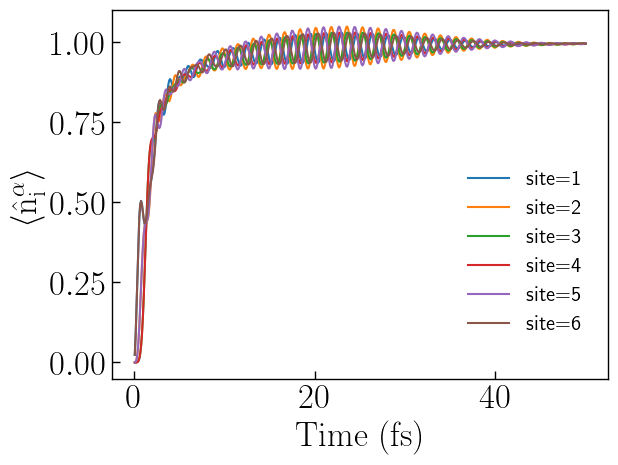

PyObject <matplotlib.legend.Legend object at 0x7f9b17355d00>

In [79]:
fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,6)
for i in sites 
    axs.plot(ts_cd, cden_ta1[:,i],label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(ts_cd, cden_ta1[:,i+1],label= "site=$(i)")#
end

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

## Local currents

In [80]:
# #### Layer 1
# fig,axs =  plt.subplots(1,1)
# site = 1
# sites = range(1,Int(n//2))
# for i in site 
#     axs.plot(ts_bc1, bcc1_ta1[:,i],label= raw"$\mathrm{\sigma=0}$",ls=":")#,alpha =1-0.2*i ) ### Charge bound current
#     # axs.plot(ts_bc1, bscx1_ta1[:,i],label= raw"$\mathrm{\sigma=x}$")
#     # axs.plot(ts_bc1, bscy1_ta1[:,i],label= raw"$\mathrm{\sigma=y}$")
#     # axs.plot(ts_bc1, bscz1_ta1[:,i],label= raw"$\mathrm{\sigma=z}$")
# end
# axs.set_ylabel(raw"$\mathrm{I^{\sigma}_i\ (e\gamma/h)}$", fontsize = fs)
# axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
# axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
# axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
# axs.yaxis.offsetText.set_fontsize(fs)
# axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
# plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

In [81]:
# #chi_f
# fig,axs = plt.subplots(1,1)
# fs=25
# axs.plot(chi_f,color= "green",lw = 0.5)#,label = raw"$\mathrm{I_R}$")

# axs.set_ylabel(raw"$\mathrm{\rho_{nd}}$", fontsize = fs)
# axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
# #axs.set_ylim([-1e-1,1e-1])
# #axs.set_ylim([-40e-1,40e-1])
# axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
# axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
# axs.yaxis.offsetText.set_fontsize(fs)
# #axs.set_xlim([100,1100])
# #axs.set_xlim([950,1050])
# axs.set_xlim([19000,21000])
# plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
# #axs.set_ylim([0.2,2.5])
# axs.axvline(250)
# plt.tight_layout()


# Plot comparison

## Current

In [1445]:
data["cc_αt_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"]

2×80000 Matrix{Float64}:
 7.19747  10.7124  9.94277  7.19396  …  0.00541077  0.00460947  0.00351676
 7.19747  10.7124  9.94277  7.19396     0.001474    0.00191989  0.00270676

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
sys:1: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


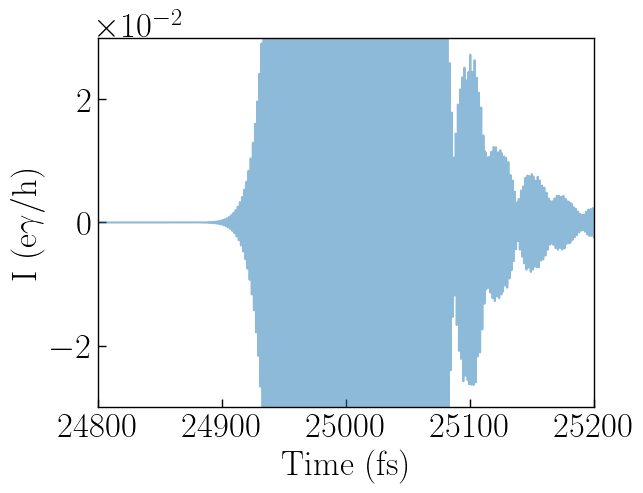

(-0.03, 0.03)

In [124]:
fig,axs = plt.subplots(1,1)
fs=25

#axs.plot(ts_cc,cc_αt[1,:],color= "green",lw = 0.5,label = raw"$\mathrm{I_R}$")
# axs.plot(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][1,:])
# # axs.plot(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
# # axs.plot(data["ts_cc_res_U_0.2+Omega_3.65+zs_0.1+js_0.0"],data["cc_αt_res_U_0.2+Omega_3.65+zs_0.1+js_0.0"][1,:],alpha=0.5)
# # axs.plot(data["ts_cc_res_U_0.01+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.01+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
# # axs.plot(data["ts_cc_res_U_0.05+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.05+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
# axs.plot(data["ts_cc_res_U_0.1+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.1+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_mt_U_0.15+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_mt_U_0.15+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)

#####axs.plot(data["ts_cc_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"],data["cc_αt_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"][1,:],alpha=0.5)

#####axs.plot(data["ts_cc_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.01"],data["cc_αt_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.01"][1,:],alpha=0.5)



#axs.plot(data["ts_cc_testA_U_0.2+Omega_3.65+zs_0.0+js_0.02"],data["cc_αt_testA_U_0.2+Omega_3.65+zs_0.0+js_0.02"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)

# axs.plot(data["ts_cc_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"],data["cc_αt_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"][1,:],alpha=0.5)
# axs.plot(data["ts_cc_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"],data["cc_αt_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"][1,:],alpha=0.5)
# axs.plot(data["ts_cc_freqs_U_0.0+Omega_0.6+zs_0.1+js_0.02"],data["cc_αt_freqs_U_0.0+Omega_0.6+zs_0.1+js_0.02"][1,:],alpha=0.5)

#axs.plot(data["ts_cc_res_U_0.4+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.4+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.05"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.05"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_U_0.4+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.4+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_U_0.8+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.8+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_U_0.8+Omega_3.65+zs_0.1+js_0.05"],data["cc_αt_res_U_0.8+Omega_3.65+zs_0.1+js_0.05"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_U_0.8+Omega_3.65+zs_0.1+js_0.08"],data["cc_αt_res_U_0.8+Omega_3.65+zs_0.1+js_0.08"][1,:],alpha=0.5)


# axs.plot(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
###axs.plot(data["ts_cc_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["cc_αt_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_test_ns_mt:U_0.4+Omega_3.65+zs_0.1+js_0.05"],data["cc_αt_test_ns_mt:U_0.4+Omega_3.65+zs_0.1+js_0.05"][1,:],alpha=0.5)
# axs.plot(data["ts_cc_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.08"],data["cc_αt_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.08"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.08"],data["cc_αt_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.08"][1,:],alpha=0.5)
#axs.plot(ts_cc,cc_αt[1,:]-cc_αt[2,:], color= "blue",ls = ":" ,lw = 1.2,alpha= 1.0,label = raw"$\mathrm{I_{Total} = (I_L - I_R)/2 }$" )
#axs.plot(data["ts_cc_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.0"],data["cc_αt_res_ns_U_0.0+Omega_3.65+zs_0.1+js_0.0"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.01"],data["cc_αt_res_ns_U_0.0+Omega_3.65+zs_0.1+js_0.01"][1,:],alpha=0.5)
# axs.plot(data["ts_cc_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.001"],data["cc_αt_res_ns_U_0.0+Omega_3.65+zs_0.1+js_0.001"][1,:],alpha=0.5)
# axs.plot(data["ts_cc_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.001"],data["cc_αt_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.001"][1,:],alpha=0.5)
axs.plot(data["ts_cc_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.001"],data["cc_αt_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.001"][1,:],alpha=0.5)
#axs.plot(data["ts_cc_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.001"],data["cc_αt_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.001"][1,:],alpha=0.5)

axs.set_ylabel(L"$\mathrm{I\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
#axs.set_ylim([-1e-3+0.5e-3,1e-3+20e-3])
#axs.set_ylim([-1e-4,1e-3])
#axs.set_xlim(7800,8500)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([350,800])
#axs.set_xlim([950,1050])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.show()
#axs.set_xlim(1900,2200)


#axs.axvline([11600])
# axs.axvline([11600+1100])
# axs.axvline([11600+2700])
#axs.axvline([11600])
axs.set_xlim(24800,25200)
axs.set_ylim(-3e-2,3e-2)
#axs.set_ylim(-3e-6,3e-6)
#axs.set_ylim(-3,3)
#axs.set_yscale("log")
#axs.set_xlim(1000,1200)

In [120]:
data["cc_αt_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.001"]
data["ts_cc_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.001"]

0.1:0.1:35000.0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
sys:1: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


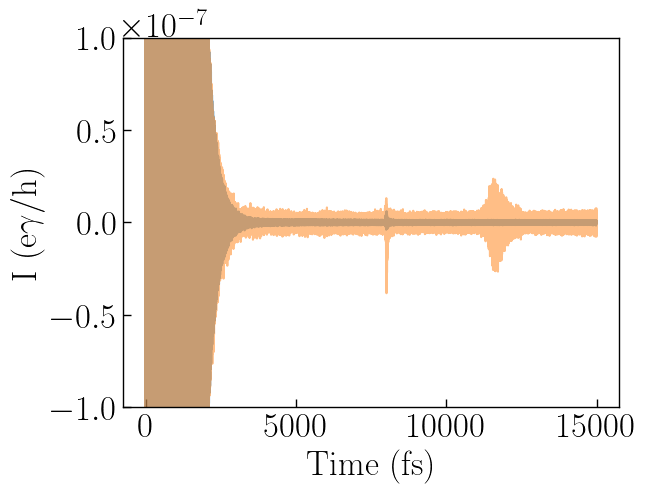

In [715]:
fig,axs = plt.subplots(1,1)
fs=25

#axs.plot(ts_cc,cc_αt[1,:],color= "green",lw = 0.5,label = raw"$\mathrm{I_R}$")
# axs.plot(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"],data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][1,:])
# axs.plot(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
axs.plot(data["ts_sc_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["sc_αxt_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][2,2,:],alpha=0.5)
axs.plot(data["ts_sc_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["sc_αxt_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][2,2,:],alpha=0.5)


axs.set_ylabel(L"$\mathrm{I\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.set_ylim([-1e-7,1e-7])
#axs.set_ylim([-1.5,1.5])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([350,800])
#axs.set_xlim([950,1050])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.show()
#axs.set_xlim(1900,2200)

#axs.set_xlim(7000,9000)

### FFT current

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


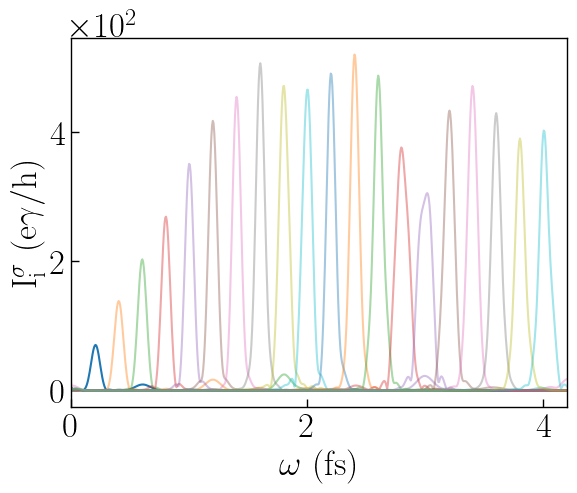

(0.0, 4.2)

In [317]:
#### Layer 1
using FFTW

fig,axs =  plt.subplots(1,1)
site = 2
sites = range(1,3)



# t0=1#10000
# tp=2000
# tf=40000
# σ_freq = 25*6  # Width of the Gaussian filter in frequency domain
# gaussian_filter = exp.(-(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))


t0=70000#19000#10000
#tp=2000
tf=150000#40000


# axs.plot(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)
# axs.plot(data["ts_cc_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cc_αt_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][1,:],alpha=0.5)

# freqs  = fftshift(fftfreq(length(data["ts_cc_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ###A_t = A_light.(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"])
# #ft_A  = fftshift(abs.(fft(A_t[t0:tf])))
# #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
# ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][1,t0:tf])))
# ###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)
####axs.plot(freqs,ftA_norm.*freqs)



# freqs  = fftshift(fftfreq(length(data["ts_cc_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ###A_t = A_light.(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"])
# #ft_A  = fftshift(abs.(fft(A_t[t0:tf])))
# #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
# ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][1,t0:tf])))
# ###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)


t0=75000#19000#10000
#tp=2000
tf=85000#40000

freqs  = fftshift(fftfreq(length(data["ts_cc_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
###A_t = A_light.(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"])
#ft_A  = fftshift(abs.(fft(A_t[t0:tf])))
#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm)





freqs  = fftshift(fftfreq(length(data["ts_cc_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
###A_t = A_light.(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"])
#ft_A  = fftshift(abs.(fft(A_t[t0:tf])))
#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)



#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_0.6+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft)# ./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)

#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_0.8+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)


#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_1.0+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_1.2+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_1.4+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_1.6+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)

ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_1.8+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_2.0+zs_0.1+js_0.02"][1,t0:tf])))
###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_2.2+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_2.4+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_2.6+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_2.8+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_3.0+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_3.2+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)

ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_3.4+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)

ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_3.6+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_3.8+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)


ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.0+Omega_4.0+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
axs.plot(freqs,ft_norm,alpha=0.4)

# freqs  = fftshift(fftfreq(length(data["ts_cc_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ft  = fftshift(abs.(fft(data["cc_αt_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][1,t0:tf]+data["cc_αt_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][2,t0:tf])))
# ###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)

# #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
# ft  = fftshift(abs.(fft(data["tbcc_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)

# #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
# ft  = fftshift(abs.(fft(data["tbcc_t_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)


axs.set_ylabel(raw"$\mathrm{I^{\sigma}_i\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{\omega\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([0,35])
#axs.set_ylim(0,0.1e-2)

#axs.set_xlim([0,35])

#axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))


# axs.axvline([7])
# axs.axvline([7+2.5/0.66])

# axs.axvline(3.65,color="red")
# axs.axvline(3.65*2,color="red")
# axs.axvline(3.65*3,color="red")
# axs.axvline(2*3.65,color="red")
#axs.set_yscale("log")
# axs.axvline([0.2])
# axs.axvline([0.4])
# axs.axvline([0.6])
# axs.axvline([0.8])
# axs.axvline([0.31*4])
# axs.axvline([0.31*6])
# axs.axvline([0.31*8])

# axs.axvline([0.31*10])
# axs.axvline([0.31*12])
#axs.axvline([0.31*12],color="blue")
# axs.axvline([0.31*14],color="blue")
# axs.axvline([0.31*16],color="blue")
# axs.axvline([0.31*20],color="blue")


axs.set_xlim([0,4.2])
#axs.set_ylim([0,10])

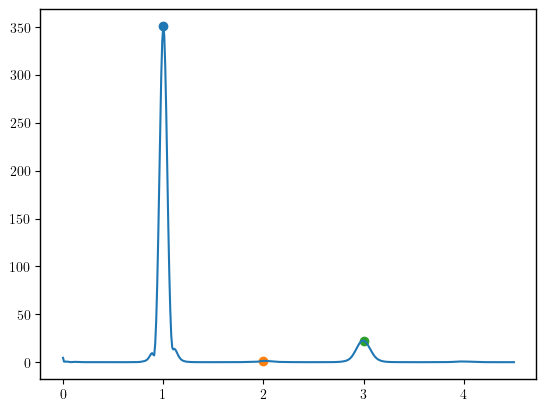

PyObject <matplotlib.collections.PathCollection object at 0x7ff33b8a9370>

In [318]:
#using DSP
#Pkg.add("Peaks") 
#using Peaks
# import Pkg;
#Pkg.add("Interpolations")
using Interpolations

#peak_indices, peak_values = DSP.findpeaks(ft)
# only its center is reported.
#fig,axs =  plt.subplots(1,1)
# wii=0.4
# freqs  = fftshift(fftfreq(length(data["ts_cc_freqs_U_0.0+Omega_$(wii)+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_$(wii)+zs_0.1+js_0.02"][1,t0:tf])))
# ft_norm = abs.(ft) 
# itp = interpolate((freqs,), ft_norm, Gridded(Linear()))
# plt.plot(0:0.01:2.0,itp.(0:0.01:2.0))
# plt.scatter(wii,itp(wii))
# plt.scatter(wii*2,itp(wii*2))
# plt.scatter(wii*3,itp(wii*3))



wii = 1.0

freqs  = fftshift(fftfreq(length(data["ts_cc_freqs_U_0.0+Omega_$(wii)+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_$(wii)+zs_0.1+js_0.02"][1,t0:tf])))
ft_norm = abs.(ft) 
itp = interpolate((freqs,), ft_norm, Gridded(Linear()))
plt.plot(0:0.01:4.5,itp.(0:0.01:4.5))
plt.scatter(wii,itp(wii))
plt.scatter(wii*2,itp(wii*2))
plt.scatter(wii*3,itp(wii*3))
#ind

#axs.plot(ind,heights)
#axs.xlim(15000,20000)

In [180]:
real(1im)

itp(0.1)

2.7411628384323365

## Optical conductivity

In [304]:
#### Layer 1
using FFTW

# fig,axs =  plt.subplots(1,1)
# site = 2
# sites = range(1,3)
using Interpolations

Ui = 0.2
ji = 0.02

data["condc3_freqs_U_$(Ui)+zs_0.1+js_$(ji)"] = []
#wss = 2.2:0.2:4.0

wss = 0.0:0.2:2.0
for ww in wss
    ft  = fftshift(real.(fft(data["cc_αt_freqs_U_$(Ui)+Omega_$(ww)+zs_0.1+js_$(ji)"][1,t0:tf])))
    ft_norm = abs.(ft) 
    itp = interpolate((freqs,), ft_norm, Gridded(Linear()))
    #println(ww,itp(ww))
    push!(data["condc3_freqs_U_$(Ui)+zs_0.1+js_$(ji)"], itp(ww*3))#maximum(abs.(ft)) )
end
wss = 2.2:0.2:4.0
for ww in wss
    ft  = fftshift(real.(fft(data["cc_αt_res_U_$(Ui)+Omega_$(ww)+zs_0.1+js_$(ji)"][1,t0:tf])))
    ft_norm = abs.(ft) 
    itp = interpolate((freqs,), ft_norm, Gridded(Linear()))
    push!(data["condc3_freqs_U_$(Ui)+zs_0.1+js_$(ji)"], itp(ww*3))#maximum(abs.(ft)) )
end
#ft_norm = abs.(ft) 
#axs.plot(freqs,ft_norm,alpha=0.4)

In [188]:
#data["condc1_freqs_U_0.0+zs_0.1+js_0.02"]
#data["condc1_freqs_U_$(Ui)+zs_0.1+js_$(ji)"]

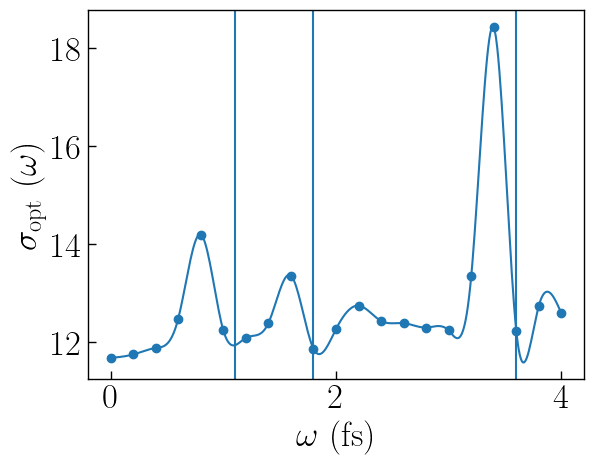

In [389]:
fig,axs =  plt.subplots(1,1)


#axs.scatter(wss,data["condc_freqs_U_0.0+zs_0.1+js_0.0"])


#axs.scatter(wss,data["condc2_freqs_U_0.0+zs_0.1+js_0.0"]) #### Note that just the jsd doesnt not chage to much the max 


# itp = interpolate(data["condc2_freqs_U_0.0+zs_0.1+js_0.0"], BSpline(Cubic(Line(OnGrid()))))
# sitp = scale(itp, wss)

# itp = interpolate((wss,), data["condc2_freqs_U_0.0+zs_0.1+js_0.0"], Gridded(Linear()))
# wn =0.2:0.1:4.0
# plt.plot(wn,itp.(wn))


# wss= 0.0:0.2:4.0
# itp = interpolate((wss,), data["condc1_freqs_U_0.0+zs_0.1+js_0.02"],Gridded(Linear()))
# wn =0.2:0.01:4.0
# plt.plot(wn,itp.(wn))

# # Define your x-values (they are uniformly spaced)
# wss = 0.0:0.2:4.0
# # Convert your data to Float64 if it isn't already

y = Float64.(data["condc0_freqs_U_0.0+zs_0.1+js_0.02"])
# Create a cubic B-spline interpolation on the index grid
itp = interpolate(y, BSpline(Cubic(Line())), OnGrid())
# Scale the interpolation to your actual x-values
sitp = scale(itp, wss)
# Define a finer grid for plotting
wn = 0.0:0.01:4.0
# Plot the smoothed interpolation
plt.plot(wn, sitp.(wn))
wii = 0.0:0.2:4.0
plt.scatter(wii, sitp.(wii))

# y = Float64.(data["condc0_freqs_U_0.2+zs_0.1+js_0.0"])
# # Create a cubic B-spline interpolation on the index grid
# itp = interpolate(y, BSpline(Cubic(Line())), OnGrid())
# # Scale the interpolation to your actual x-values
# sitp = scale(itp, wss)
# # Define a finer grid for plotting
# wn = 0.2:0.01:3.7
# # Plot the smoothed interpolation
# plt.plot(wn, sitp.(wn))
# wii = 0.0:0.2:4.0
# plt.scatter(wii, sitp.(wii))





# y = Float64.(data["condc1_freqs_U_0.2+zs_0.1+js_0.02"])
# # Create a cubic B-spline interpolation on the index grid
# itp = interpolate(y, BSpline(Cubic(Line())), OnGrid())
# # Scale the interpolation to your actual x-values
# sitp = scale(itp, wss)
# # Define a finer grid for plotting
# wn = 0.2:0.01:3.8
# wii = 0.0:0.2:4.0
# # Plot the smoothed interpolation
# plt.plot(wn, sitp.(wn))
# plt.scatter(wii, sitp.(wii))


# y = Float64.(data["condc1_freqs_U_0.0+zs_0.1+js_0.02"])
# # Create a cubic B-spline interpolation on the index grid
# itp = interpolate(y, BSpline(Cubic(Line())), OnGrid())
# # Scale the interpolation to your actual x-values
# sitp = scale(itp, wss)
# # Define a finer grid for plotting
# wn = 0.1:0.01:3.8
# wii = 0.0:0.2:4.0
# # Plot the smoothed interpolation
# plt.plot(wn, sitp.(wn))
# plt.scatter(wii, sitp.(wii))


# y = Float64.(data["condc1_freqs_U_0.2+zs_0.1+js_0.02"])
# # Create a cubic B-spline interpolation on the index grid
# itp = interpolate(y, BSpline(Cubic(Line())), OnGrid())
# # Scale the interpolation to your actual x-values
# sitp = scale(itp, wss)
# # Define a finer grid for plotting
# wn = 0.01:0.01:3.8
# wii = 0.0:0.2:4.0
# # Plot the smoothed interpolation
# plt.plot(wn, sitp.(wn))
# plt.scatter(wii, sitp.(wii))
#plt.scatter(wn,itp.(ws))




# y = Float64.(data["condc2_freqs_U_0.2+zs_0.1+js_0.02"])
# # Create a cubic B-spline interpolation on the index grid
# itp = interpolate(y, BSpline(Cubic(Line())), OnGrid())
# # Scale the interpolation to your actual x-values
# sitp = scale(itp, wss)
# # Define a finer grid for plotting
# wn = 0.2:0.01:3.8
# # Plot the smoothed interpolation
# plt.plot(wn, sitp.(wn))



# y = Float64.(data["condc3_freqs_U_0.0+zs_0.1+js_0.0"])
# # Create a cubic B-spline interpolation on the index grid
# itp = interpolate(y, BSpline(Cubic(Line())), OnGrid())
# # Scale the interpolation to your actual x-values
# sitp = scale(itp, wss)
# # Define a finer grid for plotting
# wn = 0.2:0.01:3.8
# # Plot the smoothed interpolation
# plt.plot(wn, sitp.(wn))

# axs.axvline([0.8])

# axs.axvline([1.4])

# axs.axvline([2.2])

# axs.axvline([3])

# axs.axvline([1.6])

# axs.axvline([2.2])

#### After E_t

axs.axvline([1.1])
axs.axvline([1.8])
# axs.axvline([2.2])
# axs.axvline([3.0])
axs.axvline([3.6])


axs.set_ylabel(raw"$\mathrm{\sigma_{opt}}\ (\omega)$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{\omega\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)



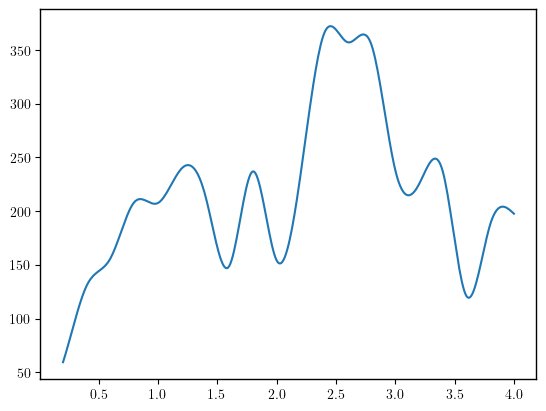

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7ff102807340>

In [246]:
# using Pkg
# Pkg.add("Interpolations")  # Run only if needed

using Interpolations

# Define your x-values (they are uniformly spaced)
wss = 0.0:0.2:4.0

# Convert your data to Float64 if it isn't already
y = Float64.(data["condc1_freqs_U_0.0+zs_0.1+js_0.02"])

# Create a cubic B-spline interpolation on the index grid
itp = interpolate(y, BSpline(Cubic(Line())), OnGrid())

# Scale the interpolation to your actual x-values
sitp = scale(itp, wss)

# Define a finer grid for plotting
wn = 0.2:0.01:4.0

# Plot the smoothed interpolation
plt.plot(wn, sitp.(wn))


## Classical spin

In [43]:
data["cspins_tax_testA_U_0.0+Omega_3.65+zs_0.0+js_0.0"]

LoadError: KeyError: key "cspins_tax_testA_U_0.0+Omega_3.65+zs_0.0+js_0.0" not found

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
sys:1: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


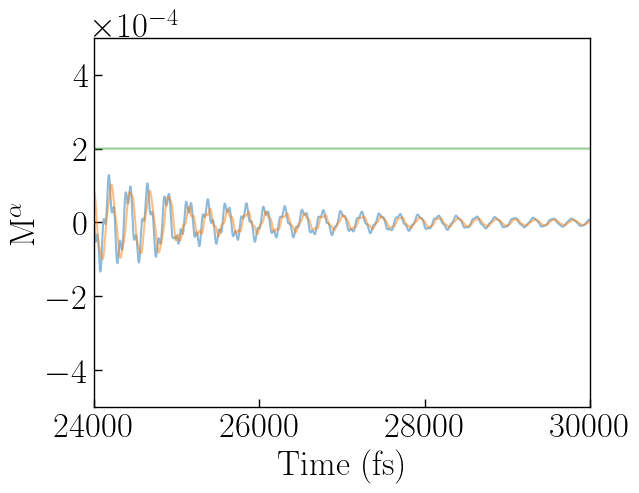

In [220]:
fig,axs = plt.subplots(1,1)
site = 5
fs=25
# U0s = [0.0,0.4,1.0]#0.0:0.2:1.0
# ws = 3.65#[2.43,3.04,3.65,4.56,6.08]#[1.6,2.4,3.6]
# zs= 0.1#[0.1,0.2,0.3]#0.1#[0.0,0.02]
# js= [0.05,0.08,0.1]#[0.1,0.2,0.3]#[0.0,0.02]
# axs.plot(data["ts_cs_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"],data["cspins_tax_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,1,2])

#axs.plot(data["ts_cs_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
#axs.plot(data["ts_cs_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.0"],data["cspins_tax_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,1,2],alpha=0.5)
#axs.plot(data["ts_cs_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.0"],data["cspins_tax_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,1,2])
##### axs.plot(data["ts_cs_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"],data["cspins_tax_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"][:,1,2])
##### axs.plot(data["ts_cs_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
# axs.plot(data["ts_cs_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
# axs.plot(data["ts_cs_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)

# axs.plot(data["ts_cs_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)

# axs.plot(data["ts_cs_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)

#axs.plot(data["ts_cs_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)

#axs.plot(data["ts_cs_res_U_0.1+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.1+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
# axs.plot(data["ts_cs_res_U_0.15+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.15+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
# axs.plot(data["ts_cs_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)

#axs.plot(data["ts_cs_res_U_0.2+Omega_3.65+zs_0.1+js_0.01"],data["cspins_tax_res_U_0.2+Omega_3.65+zs_0.1+js_0.01"][:,1,2],alpha=0.5)

#axs.plot(data["ts_cs_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)


####axs.plot(data["ts_cs_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,1,3],alpha=0.2)

#axs.plot(data["ts_cs_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][:,1,3],alpha=0.5)


#axs.plot(data["ts_cs_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][:,1,3],alpha=0.5)

# axs.plot(data["ts_cs_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.05"],data["cspins_tax_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.05"][:,1,3],alpha=0.5)

#axs.plot(data["ts_cs_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][:,1,1])

# axs.plot(data["ts_cs_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"][:,1,3])

# axs.plot(data["ts_cs_test_ns:U_0.0+Omega_4.56+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.0+Omega_4.56+zs_0.1+js_0.02"][:,1,3],alpha=0.8)

# #axs.plot(data["ts_cs_test_ns:U_0.4+Omega_2.43+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.4+Omega_2.43+zs_0.1+js_0.02"][:,1,3],alpha=0.3)

# axs.plot(data["ts_cs_test_ns:U_0.4+Omega_4.56+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.4+Omega_4.56+zs_0.1+js_0.02"][:,1,3],alpha=0.6)

# axs.plot(data["ts_cs_test_ns:U_1.0+Omega_4.56+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_1.0+Omega_4.56+zs_0.1+js_0.02"][:,1,3],alpha=0.3)

#axs.plot(data["ts_cs_test_ns:U_0.0+Omega_3.04+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.0+Omega_3.04+zs_0.1+js_0.02"][:,1,3],ls=":")

#axs.plot(data["ts_cs_test_ns:U_0.0+Omega_4.56+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.0+Omega_4.56+zs_0.1+js_0.02"][:,1,3],alpha=0.5)

#axs.plot(data["ts_cs_test_ns:U_0.0+Omega_6.08+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.0+Omega_6.08+zs_0.1+js_0.02"][:,1,3],alpha=0.5)

#axs.plot(data["ts_cs_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_1.0+Omega_3.04+zs_0.1+js_0.02"][:,1,2],ls=":")


#axs.plot(data["ts_cs_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"],data["cspins_tax_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"][:,1,2],alpha=0.5)

#axs.plot(data["ts_cs_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"],data["cspins_tax_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
#axs.plot(data["ts_cs_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"],data["cspins_tax_freqs_U_0.0+Omega_0.8+zs_0.1+js_0.02"][:,1,1],alpha=0.5)

# axs.plot(data["ts_cs_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,1,2],alpha=0.5)

# sumx1 = sum(data["cspins_tax_res_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,1:2:end,2],dims=2 )
# sumx2= sum(data["cspins_tax_res_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,2:2:end,2],dims=2 )

# axs.plot(data["ts_cs_freqs_U_0.2+Omega_0.4+zs_0.1+js_0.02"],sumx1,alpha=0.5)

# axs.plot(data["ts_cs_freqs_U_0.2+Omega_0.4+zs_0.1+js_0.02"],sumx1-sumx2,alpha=0.5)



##axs.plot(data["ts_cs_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"],data["cspins_tax_res_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
#axs.plot(data["ts_cs_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_ns_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
#axs.plot(data["ts_cs_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["cspins_tax_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,1,2],alpha=0.5)
# sumx1 = sum(data["cspins_tax_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.01"][:,1:2:end,2],dims=2 )
# sumx2= sum(data["cspins_tax_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.01"][:,2:2:end,2],dims=2 )

# axs.plot(data["ts_cs_res_ns_U_0.2+Omega_3.65+zs_0.1+js_0.02"],sumx1,alpha=0.5)


sumx1 = sum(data["cspins_tax_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.02"][:,1:2:end,2],dims=2 )
sumx2= sum(data["cspins_tax_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.02"][:,2:2:end,2],dims=2 )

#axs.plot(data["ts_cs_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.01"],sumx1,alpha=0.5)
axs.plot(data["ts_cs_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.02"],sumx1-sumx2,alpha=0.5)
#axs.plot(data["ts_cs_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.02"],sumx1 ,alpha=0.5)

sumx1 = sum(data["cspins_tax_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,1:2:end,2],dims=2 )
sumx2= sum(data["cspins_tax_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,2:2:end,2],dims=2 )

#axs.plot(data["ts_cs_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.01"],sumx1,alpha=0.5)
axs.plot(data["ts_cs_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.02"],sumx1-sumx2,alpha=0.5)


sumx1 = sum(data["cspins_tax_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,1:2:end,1],dims=2 )
sumx2= sum(data["cspins_tax_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,2:2:end,1],dims=2 )

#axs.plot(data["ts_cs_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.01"],sumx1,alpha=0.5)
axs.plot(data["ts_cs_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.02"],(sumx1-sumx2)*1e-5,alpha=0.5)


# axs.plot(data["ts_cs_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.001"],data["cspins_tax_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.001"][:,1,1],alpha=0.5)
# axs.plot(data["ts_cs_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.01"],data["cspins_tax_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.01"][:,1,1],alpha=0.5)
#axs.plot(data["ts_cs_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.001"],data["cspins_tax_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.001"][:,1,2],alpha=0.5)

#axs.plot(ts_cs,cspins_tax[:,site+2,3])
axs.set_ylabel(L"$\mathrm{M^{\alpha}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
#axs.set_ylim([-10e-8,+10e-8])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([350,800]1
#axs.set_xlim([950,1050])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
# axs.axvline([4000])
# axs.axvline([3000])
# axs.axvline([11000])
# axs.axvline([13000])
#axs.axvline([8000])

#axs.set_ylim([-0.5e-1,0.5e-1])

#axs.set_ylim([-0.5,0.5])
#axs.set_ylim([1-0.1e-10,1+0.1e-10])
#axs.set_ylim([1-1e-6,1+1e-6])
#axs.set_xlim(7800,15200)

#axs.set_xlim(3000,25000)
axs.set_ylim([-5e-4,5e-4])

axs.set_xlim(24000,30000)
plt.show()
# 2
#axs.set_ylim(-1,1)
#:qaxs.set_xlim(7000,12000)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


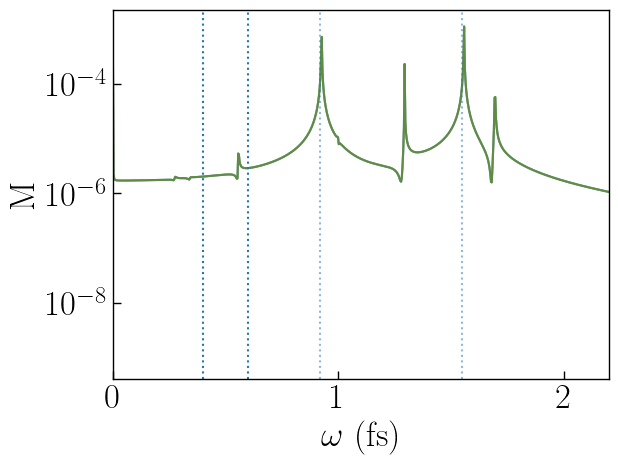

(0.0, 2.2)

In [496]:
#### Layer 1
using FFTW

fig,axs =  plt.subplots(1,1)
site = 2
sites = range(1,3)


t0=50000#19000#10000
#tp=2000
tf=70000#40000


freqs  = fftshift(fftfreq(length(data["ts_cs_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
ft  = fftshift(abs.(fft(data["cspins_tax_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"][t0:tf,1,2])))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm)


ft  = fftshift(abs.(fft(data["cspins_tax_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"][t0:tf,1,2])))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.5)


# ft  = fftshift(abs.(fft(data["cspins_tax_freqs_U_0.0+Omega_1.0+zs_0.1+js_0.02"][t0:tf,1,2])))
# ft_norm = abs.(ft) #./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)


# ft  = fftshift(abs.(fft(data["cspins_tax_freqs_U_0.0+Omega_2.0+zs_0.1+js_0.02"][t0:tf,1,2])))
# ft_norm = abs.(ft) #./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)


ft  = fftshift(abs.(fft(data["cspins_tax_res_U_0.0+Omega_4.0+zs_0.1+js_0.02"][t0:tf,1,2])))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.5)


# ft  = fftshift(abs.(fft(data["cspins_tax_freqs_U_0.0+Omega_0.8+zs_0.1+js_0.02"][t0:tf,8,2])))
# ft_norm = abs.(ft) #./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)


 axs.axvline([0.4],alpha=1,ls=":")
 axs.axvline([0.6],alpha=1,ls=":")

 axs.axvline([0.92],alpha=0.5,ls=":")

 axs.axvline([1.55],alpha=0.5,ls=":")


# freqs  = fftshift(fftfreq(length(data["ts_cc_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ###A_t = A_light.(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"])
# #ft_A  = fftshift(abs.(fft(A_t[t0:tf])))
# #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
# ft  = fftshift(abs.(fft(data["cc_αt_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"][1,t0:tf])))
# ###ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
# ft_norm = abs.(ft) #./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.4)

axs.set_ylabel(raw"$\mathrm{M}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{\omega\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([0,35])
#axs.set_ylim(0,0.1e-2)

#axs.set_xlim([0,35])

#axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))


#axs.set_ylim(0,0.1e-3)
axs.set_yscale("log")
axs.set_xlim([0,2.2])

In [26]:
wi=(0.001*3/2)*(2pi/10)^2
2pi/wi

10610.32953945969

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


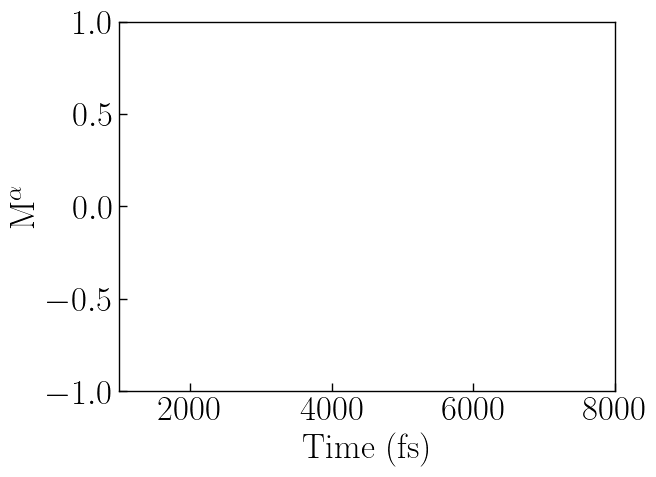

(1000.0, 8000.0)

In [1026]:
fig,axs = plt.subplots(1,1)
site = 5

# axs.plot(data["ts_cs_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"][:,1,2])

# axs.plot(data["ts_cs_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][:,1,2],alpha=0.5)

#axs.plot(data["ts_cs_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"][:,1,3],alpha=0.5)

# axs.plot(data["ts_cs_test_ns:U_1.0+Omega_3.04+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_1.0+Omega_3.04+zs_0.1+js_0.02"][:,1,3],ls=":")

# #axs.plot(data["ts_cs_test_ns:U_0.0+Omega_4.56+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_0.0+Omega_4.56+zs_0.1+js_0.02"][:,1,3],alpha=0.5)

# axs.plot(data["ts_cs_test_ns:U_1.0+Omega_6.08+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_1.0+Omega_6.08+zs_0.1+js_0.02"][:,1,3],alpha=0.5)

#axs.plot(data["ts_cs_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"],data["cspins_tax_test_ns:U_1.0+Omega_3.04+zs_0.1+js_0.02"][:,1,2],ls=":")

#axs.plot(ts_cs,cspins_tax[:,site+2,3])
axs.set_ylabel(L"$\mathrm{M^{\alpha}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.set_ylim([-1,1])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([350,800])
#axs.set_xlim([950,1050])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.show()
axs.set_xlim(1000,8000)

In [ ]:
1

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


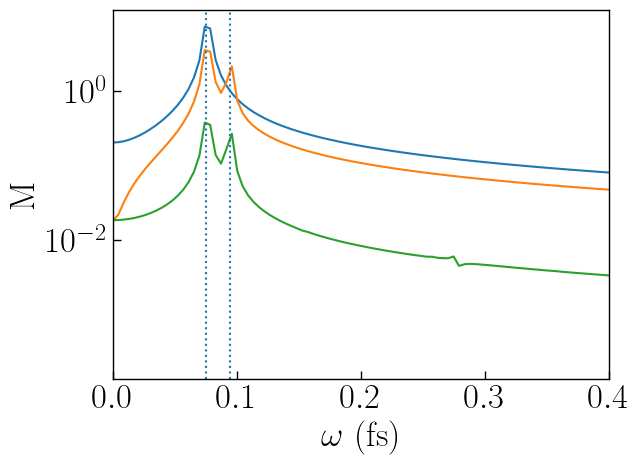

(0.0, 0.4)

In [740]:
using FFTW

fig,axs =  plt.subplots(1,1)
site = 2
sites = range(1,3)


# t0=74000#19000#10000
# #tp=2000
# tf=91000#40000

t0=10000#19000#10000
#tp=2000
tf=14000#40000

sumx1 = sum(data["cspins_tax_res_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,1:2:end,2],dims=2 )
sumx2= sum(data["cspins_tax_res_U_0.2+Omega_3.6+zs_0.1+js_0.02"][:,2:2:end,2],dims=2 )

freqs  = fftshift(fftfreq(length(data["ts_cs_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
ft  = fftshift(abs.(fft(sumx1[t0:tf] -sumx2[t0:tf]  )))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs/3.6,ft_norm)


#freqs  = fftshift(fftfreq(length(data["ts_cs_freqs_U_0.0+Omega_0.2+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
ft  = fftshift(abs.(fft(sumx1[t0:tf]  )))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs/3.6,ft_norm)





#freqs  = fftshift(fftfreq(length(data["ts_cs_freqs_U_0.0+Omega_0.4+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
ft  = fftshift(abs.(fft(data["cspins_tax_res_U_0.2+Omega_3.6+zs_0.1+js_0.02"][t0:tf,10,2])))
ft_norm = abs.(ft) #./maximum(abs.(ft))
axs.plot(freqs/3.6,ft_norm)



axs.set_ylabel(raw"$\mathrm{M}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{\omega\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([0,35])
#axs.set_ylim(0,0.1e-2)
##axs.axvline([0.104],alpha=1,ls=":")
##axs.axvline([0.07],alpha=1,ls=":")

#axs.axvline([0.27/3.6],alpha=1,ls=":")
axs.axvline([0.27/3.6],alpha=1,ls=":")
axs.axvline([0.34/3.6],alpha=1,ls=":")

#axs.set_xlim([0,35])

#axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))


#axs.set_ylim(0,200000e-5)
axs.set_yscale("log")
axs.set_xlim([0,0.4])
###### ;
    


In [212]:
### average magnetization per site
#mag = ["avgx_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"]
#mag = ["avgy_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"]
#mag = ["avgz_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"]
l=length(data["cspins_tax_res_U_0.0+Omega_3.65+zs_0.3+js_0.02"][:,Int(1),2])
data["avgx_cspins_tax_res_U_0.0+Omega_3.65+zs_0.3+js_0.02"] = zeros(Float64,l)
for i in 1:2:(Int(n//2))
    
    # ft  = fftshift(abs.(fft(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"][:,Int(i),2])))
    # freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.0"][:,Int(i),2])))*2pi/0.1#*1000
    # ft_norm = abs.(ft) ./maximum(abs.(ft))
    
    data["avgx_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.02"] += data["cspins_tax_test_ns:U_1.0+Omega_4.56+zs_0.3+js_0.02"][:,Int(i),3] - data["cspins_tax_test_ns:U_1.0+Omega_4.56+zs_0.3+js_0.02"][:,Int(i+1),3]
    
    #println(i)
    #println(ft_norm )

end
l
#data["avgx_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"] 
#ft_norm 
data["avgx_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.02"] += data["avgx_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.02"]/10 

39461-element Vector{Float64}:
  0.005420157481612314
  0.010830061240844941
  0.01622338975600314
  0.021593839493906482
  0.026935114262360473
  0.03224091728823547
  0.03750496343617406
  0.04272100838287013
  0.047882879899688105
  0.05298449983724729
  0.05801989352255342
  0.06298318935518757
  0.06786861676011038
  ⋮
 -8.781388295219678e-8
 -8.900240209511763e-8
 -9.008257734365584e-8
 -9.105416696819456e-8
 -9.191719076634097e-8
 -9.267186264355258e-8
 -9.331839089217534e-8
 -9.385685857237107e-8
 -9.42873461899891e-8
 -9.461012860069094e-8
 -9.482567604904962e-8
 -9.493447311346357e-8

In [741]:
#ft_norm 
# for i in 1:2:Int(n//2)
#     println(i)
# end
#data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"][:,:,3]

In [742]:
#length(freqs)

In [91]:
#ft_norm

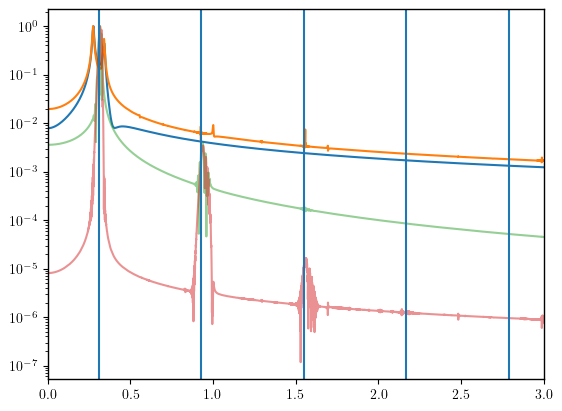

In [1104]:
using FFTW
# using Pkg
# Pkg.add("FFTW")
fig,axs = plt.subplots(1,1)




t0=70000
tf=85000

ft  = fftshift(abs.(fft(data["cspins_tax_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,2,2])))
freqs  = fftshift(fftfreq(length(data["cspins_tax_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,1,2])))*2pi/0.1#*1000
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm)



# t0=30000
# tf=70000

t0=10000#72000
tf=120000#90000

ft  = fftshift(abs.(fft(data["cspins_tax_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,2,2])))
freqs  = fftshift(fftfreq(length(data["cspins_tax_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,2,2])))*2pi/0.1#*1000
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm)



t0=10000#72000
tf=150000#90000
# t0=30000
# tf=70000

ft  = fftshift(abs.(fft(data["cspins_tax_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"][t0:tf,6,2])))
freqs  = fftshift(fftfreq(length(data["cspins_tax_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"][t0:tf,1,2])))*2pi/0.1#*1000
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.5)



t0=10000#72000
tf=150000#90000
# t0=30000
# tf=70000

ft  = fftshift(abs.(fft(data["cspins_tax_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf,6,2])))
freqs  = fftshift(fftfreq(length(data["cspins_tax_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf,1,2])))*2pi/0.1#*1000
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm,alpha=0.5)


# t0=10000#72000
# tf=150000#90000
# # t0=30000
# # tf=70000

# ft  = fftshift(abs.(fft(data["cspins_tax_res_U_0.2+Omega_3.65+zs_0.1+js_0.01"][t0:tf,6,2])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_res_U_0.2+Omega_3.65+zs_0.1+js_0.01"][t0:tf,1,2])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)



#################################################
# t0=10000
# tf=38000

# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,2,3])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,1,2])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs/0.34,ft_norm)
#axs.plot(freqs,data["avgx_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"][t0:tf])



# t0=35000
# tf=40000

# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf,2,3])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf,1,2])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs/0.34,ft_norm)

# ft  = fftshift(abs.(fft(data["avgx_cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.02"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.02"][t0:tf,1,3])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)

# t0=20000
# tf=40000

# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.08"][t0:tf,2,3])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.08"][t0:tf,1,3])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)


# t0=30000
# tf=60000

# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.08"][t0:tf,2,3])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.08"][t0:tf,1,3])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)


# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"][t0:tf,11,3])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.02"][t0:tf,1,3])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm.^2)
#################################################



# t0=10000
# tf=18000

# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,2,2])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,1,2])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)



# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][t0:tf,2,2])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][t0:tf,1,2])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)

# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.0"][t0:tf,1,3])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.3+js_0.0"][t0:tf,1,3])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm.^2)

# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns:U_0.0+Omega_3.04+zs_0.1+js_0.02"][t0:tf,11,3])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"][t0:tf,11,3])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)

# # # #################################################

# ft  = fftshift(abs.(fft(data["cspins_tax_test_ns:U_1.0+Omega_3.04+zs_0.1+js_0.02"][t0:tf,11,3])))
# freqs  = fftshift(fftfreq(length(data["cspins_tax_test_ns:U_1.0+Omega_2.43+zs_0.1+js_0.02"][t0:tf,11,3])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,ls=":")

#axs.axvline([0.275],color="red")
# axs.axvline([0.275*2],color="red")
#axs.axvline([0.275*6],color="red")
#axs.axvline([0.275*6],color="red")

#axs.axvline([0.34])
#axs.axvline([0.34*3])
# axs.axvline([0.34*2])
# axs.axvline([0.34*3])

#axs.axvline([1/3.6])



#axs.axvline([0.34])

axs.axvline([0.31])

axs.axvline([0.31*3])

axs.axvline([0.31*5])

axs.axvline([0.31*7])

axs.axvline([0.31*9])

#axs.axvline([0.31*11])

# axs.axvline([0.31*13])

# axs.axvline([0.31*15])

# axs.axvline([0.34*3])

# axs.axvline([0.34*5])

axs.set_xlim([0.,3])


#axs.set_ylim([0,2e-3])

axs.set_yscale("log")
#axs.plo(ft_norm)

#axs


In [740]:
length(data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.0"][:,1,3])

40000

In [607]:
data["cspins_tax_test_ns:U_0.0+Omega_2.43+zs_0.1+js_0.02"]



0.1:0.1:4000.0

## Spin densities

In [1]:
data["sneq_ta1x_test_ns:U_0.0+Omega_3.04+zs_0.1+js_0.02"][t0:tf,11,3]

data["ts_sn_test_ns:U_0.0+Omega_3.04+zs_0.1+js_0.02"][t0:tf]

LoadError: UndefVarError: `data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [146]:
fig,axs = plt.subplots(1,1)
#plt.plot(data[f"cspins_f_{name1}"][:,0],data[f"cspins_f_{name1}"][:,13])
fs=25
site = 5


t0=1#10000
tf=150000
#mag = sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2

# axs.plot(data["ts_sn_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf],data["sneq_ta1x_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,site,3],label = raw"$\alpha=x$")
# axs.plot(data["ts_sn_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf],data["sneq_ta1x_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,site+1,3],label = raw"$\alpha=x$",alpha=0.5)



axs.plot(data["ts_sn_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.01"][t0:tf],data["sneq_ta1x_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.01"][t0:tf,site,3],label = raw"$\alpha=x$",alpha=0.5)

axs.plot(data["ts_sn_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.01"][t0:tf],data["sneq_ta1x_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.01"][t0:tf,site+1,3],label = raw"$\alpha=x$",alpha=0.5)

#axs.plot(data["ts_sn_test_ns_mt:U_0.4+Omega_3.65+zs_0.1+js_0.08"][t0:tf],data["sneq_ta1x_test_ns_mt:U_0.4+Omega_3.65+zs_0.1+js_0.08"][t0:tf,site,1],label = raw"$\alpha=x$")

#axs.plot(data["ts_sn_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.08"][t0:tf],data["sneq_ta1x_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.08"][t0:tf,site,1],label = raw"$\alpha=x$",alpha=0.5)
#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site+1,3],label = raw"$\alpha=x$",alpha=0.5)

#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,site,3],label = raw"$\alpha=y$",alpha=0.5)
#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3],label = raw"$\alpha=z$",alpha=0.5)
# axs.plot(ts_sn,sneq_ta1x[:,site,2],label = raw"$\alpha=y$")
# axs.plot(ts_sn,sneq_ta1x[:,site,3],label = raw"$\alpha=z$")
#axs.plot(ts_sn,mag,label = raw"$mag$")
#sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2

plt.ylim([-0.1e-4,0.1e-4])

axs.set_ylabel(raw"$\langle\mathrm{\hat{S}^{\alpha}_{i}}\rangle_{\mathrm{neq}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.75))
# axs.axvline(800)
axs.axvline(8000)
#plt.xlim([1800,2400])
#plt.xlim([800,1800])
#plt.xlim([7800,8800])

#plt.xlim([3800,4800])

LoadError: KeyError: key "ts_sn_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.01" not found

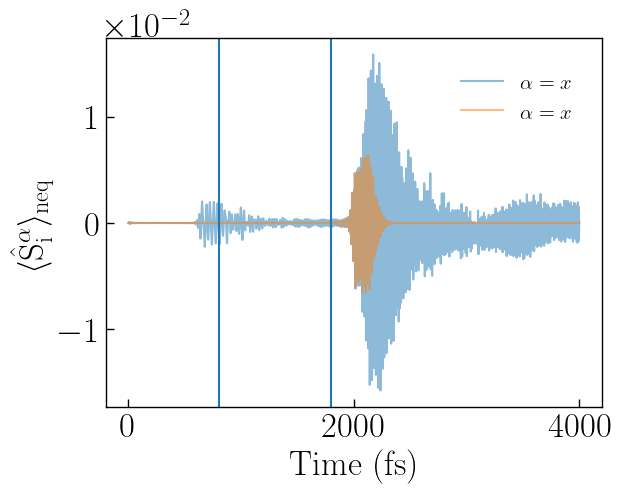

PyObject <matplotlib.lines.Line2D object at 0x7f3fd970ca90>

In [1395]:
### fft with gaussian filter 
# Signal in time with gaussian pulse 
# Define a Gaussian filter in the frequency domain
t0=1#10000
tp=2000
tf=40000
σ_freq = 25*6  # Width of the Gaussian filter in frequency domain
gaussian_filter = exp.(-(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf].-tp).^2 / (σ_freq^2))
# Apply the Gaussian filter
filtered_signal = data["sneq_ta1x_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3].* gaussian_filter

fig,axs = plt.subplots(1,1)
#plt.plot(data[f"cspins_f_{name1}"][:,0],data[f"cspins_f_{name1}"][:,13])
fs=25
site = 5



#mag = sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2
##axs.plot(data["ts_sn_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.0"][t0:tf,site,1],label = raw"$\alpha=x$")

axs.plot(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3],label = raw"$\alpha=x$",alpha=0.5)
axs.plot(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],filtered_signal,label = raw"$\alpha=x$",alpha=0.5)
#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site+1,3],label = raw"$\alpha=x$",alpha=0.5)

#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,site,3],label = raw"$\alpha=y$",alpha=0.5)
#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3],label = raw"$\alpha=z$",alpha=0.5)
# axs.plot(ts_sn,sneq_ta1x[:,site,2],label = raw"$\alpha=y$")
# axs.plot(ts_sn,sneq_ta1x[:,site,3],label = raw"$\alpha=z$")
#axs.plot(ts_sn,mag,label = raw"$mag$")
#sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2
#plt.ylim([-0.1e-8,0.1e-8])
axs.set_ylabel(raw"$\langle\mathrm{\hat{S}^{\alpha}_{i}}\rangle_{\mathrm{neq}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.75))
axs.axvline(800)
axs.axvline(1800)
#gaussian_filter

In [539]:
data["sneq_ta1x_res_U_0.0+Omega_3.65+zs_0.1+js_0.1"]

LoadError: KeyError: key "sneq_ta1x_res_U_0.0+Omega_3.65+zs_0.1+js_0.1" not found

In [538]:
t0=1#10000
tp=2000
tf=40000
# σ_freq = 25*40  # Width of the Gaussian filter in frequency domain
# gaussian_filter = exp.(-(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf].-tp).^2 / (σ_freq^2))
# # Apply the Gaussian filter
# filtered_signal = data["sneq_ta1x_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3].* gaussian_filter

fig,axs = plt.subplots(1,1)
#plt.plot(data[f"cspins_f_{name1}"][:,0],data[f"cspins_f_{name1}"][:,13])
fs=25
site = 5



t0=1#10000
tp=15000
tf=150000

ft  = fftshift(abs.(fft(data["sneq_ta1x_res_U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3])))
freqs  = fftshift(fftfreq(length(data["ts_sn_res_U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf])))*2pi/0.1#*1000
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm)



# t0=1#10000
# tp=15000
# tf=25000

# ft  = fftshift(abs.(fft(data["sneq_ta1x_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3])))
# freqs  = fftshift(fftfreq(length(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)
# #mag = sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2
# ##axs.plot(data["ts_sn_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.0"][t0:tf,site,1],label = raw"$\alpha=x$")





# t0=1#10000
# tp=2000
# tf=40000

# σ_freq = 25*4  # Width of the Gaussian filter in frequency domain
# gaussian_filter = exp.(-(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf].-tp).^2 / (σ_freq^2))
# # Apply the Gaussian filter
# filtered_signal = data["sneq_ta1x_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3].* gaussian_filter
# ft  = fftshift(abs.(fft(filtered_signal)))
# freqs  = fftshift(fftfreq(length(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)


# axs.plot(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3],label = raw"$\alpha=x$",alpha=0.5)
# axs.plot(data["ts_sn_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],filtered_signal,label = raw"$\alpha=x$",alpha=0.5)
#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site+1,3],label = raw"$\alpha=x$",alpha=0.5)

#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,site,3],label = raw"$\alpha=y$",alpha=0.5)
#axs.plot(data["ts_sn_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf],data["sneq_ta1x_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,site,3],label = raw"$\alpha=z$",alpha=0.5)
# axs.plot(ts_sn,sneq_ta1x[:,site,2],label = raw"$\alpha=y$")
# axs.plot(ts_sn,sneq_ta1x[:,site,3],label = raw"$\alpha=z$")
#axs.plot(ts_sn,mag,label = raw"$mag$")
#sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2
#plt.ylim([-0.1e-8,0.1e-8])
axs.set_ylabel(raw"$\langle\mathrm{\hat{S}^{\alpha}_{i}}\rangle_{\mathrm{neq}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{\omega\ (THz)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.75))
axs.set_xlim([0,2])
# axs.axvline(800)
# axs.axvline(1800)

LoadError: KeyError: key "sneq_ta1x_res_U_0.0+Omega_3.65+zs_0.1+js_0.1" not found

## Charge densities

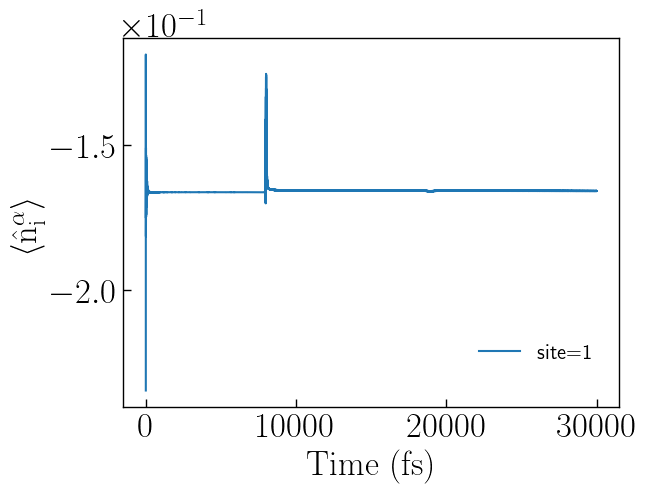

PyObject <matplotlib.legend.Legend object at 0x7f31436b40d0>

In [32]:
fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,Int(n//5))
for i in site 
    axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,i],label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,i+1],label= "site=$(i)")#
        #axs.plot(data["ts_cd_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,i],label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,i+1]-data["cden_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,i],label= "site=$(i)")#
end

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_ylim(-3e-3,1e-3)
#axs.set_ylim(-0.6,0.2)
#axs.set_xlim([7900,8200])

plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


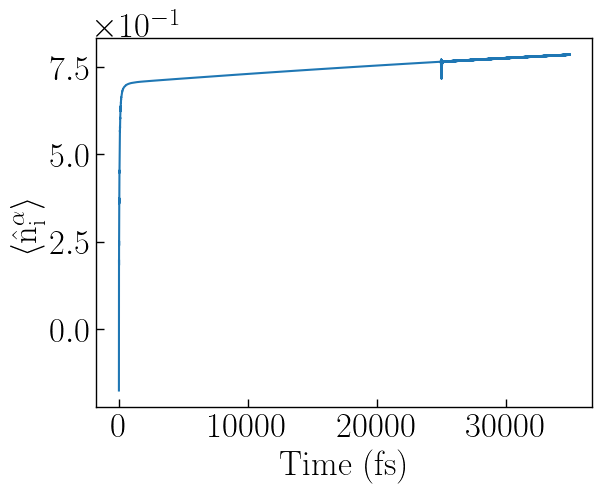

PyObject <matplotlib.legend.Legend object at 0x7f29c8e46310>

In [148]:
fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,Int(n//5))

axs.plot(data["ts_cd_res_ns_mtp_U_0.1+Omega_3.6+zs_0.1+js_0.01"], data["cden_ta1_res_ns_mtp_U_0.1+Omega_3.6+zs_0.1+js_0.01"][:,2])#,alpha =1-0.2*i ) ### Charge bound current
#axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,2])


#axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"][:,5])#,alpha =1-0.2*i ) ### Charge bound current
# axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"][:,6])

# axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"][:,6+4])
# axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"][:,6+4+4+4])
# axs.plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"], data["cden_ta1_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"][:,6],alpha=1,ls=":")

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_ylim(-3e-3,1e-3)
#axs.set_ylim(-0.6,0.2)
#axs.set_xlim([7900,8200])

plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

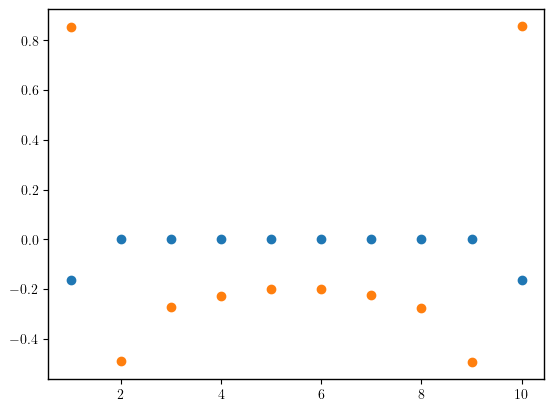

PyObject <matplotlib.collections.PathCollection object at 0x7f2ff551d160>

In [196]:
fig,axs =  plt.subplots(1,1)
site = 5
tff=180000
# fig,axs =  plt.subplots(1,1)
# site = 1 
# sites = range(1,Int(n//5))
axs.scatter(range(1,10), data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][tff,1:4:end,])
axs.scatter(range(1,10), data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][tff,2:4:end,])

# axs.scatter(range(1,10), data["cden_ta1_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"][tff,3:4:end,],alpha=0.5)
# axs.scatter(range(1,10), data["cden_ta1_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"][tff,4:4:end,],alpha=0.5)

#axs.set_ylim(-0.5e-2,0.5e-2)


#axs.scatter(range(1,20), data["cden_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][tff,2:2:end,]- data["cden_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][tff,1:2:end,],alpha=0.5)
# axs.scatter(range(1,20),cden_ta1[31000,1:2:end,],label= "site=$(site)")#,alpha =1-0.2*i ) ### Charge bound current
# axs.scatter(range(1,20),cden_ta1[31000,2:2:end,],label= "site=$(site)")


In [1]:
#testA_U_0.0+Omega_3.65+zs_0.0+js_0.02

data["cden_ta1_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"]

LoadError: UndefVarError: `data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

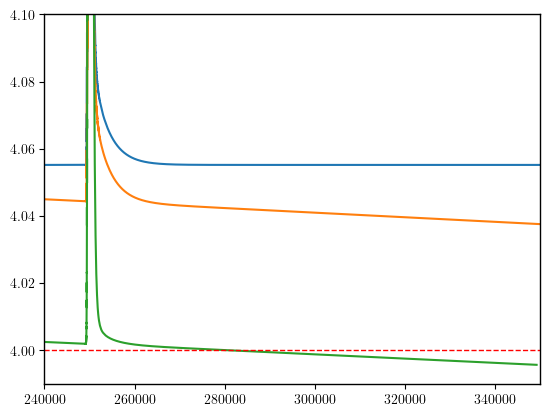

(240000.0, 350000.0)

In [155]:
#tff=10
# sg1 = sum(data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,1:2:end],dims=2)
# se1 = sum(data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,2:2:end],dims=2)
# plot(sg1-se1)
# sg1 = sum(data["cden_ta1_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"][:,1:2:end],dims=2)
# se1 = sum(data["cden_ta1_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"][:,2:2:end],dims=2)

# sg2 = sum(data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,3:2:end],dims=2)
# se2 = sum(data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,4:2:end],dims=2)
# sg1 = sum(data["cden_ta1_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"][:,1:2:end],dims=2)
# se1 = sum(data["cden_ta1_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"][:,2:2:end],dims=2)
# plot(sg1-se1)
# sg1 = sum(data["cden_ta1_testA_U_0.2+Omega_3.65+zs_0.0+js_0.02"][:,1:2:end],dims=2)
# se1 = sum(data["cden_ta1_testA_U_0.2+Omega_3.65+zs_0.0+js_0.02"][:,2:2:end],dims=2)
# #plot(-sg1-se1)
# ###plot(sg1)
#plot(data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,1])
# #plot(se1)
# plot(sg1-se1)


sg1 = sum(data["cden_ta1_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.0"][:,1:2:end],dims=2)
se1 = sum(data["cden_ta1_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.0"][:,2:2:end],dims=2)
plot(sg1-se1)


sg1 = sum(data["cden_ta1_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.001"][:,1:2:end],dims=2)
se1 = sum(data["cden_ta1_res_ns_mtp_U_0.0+Omega_3.6+zs_0.1+js_0.001"][:,2:2:end],dims=2)
plot(sg1-se1)
sg1 = sum(data["cden_ta1_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.001"][:,1:2:end],dims=2)
se1 = sum(data["cden_ta1_res_ns_mtp_U_0.2+Omega_3.6+zs_0.1+js_0.001"][:,2:2:end],dims=2)
#plot(-sg1-se1)
###plot(sg1)
#plot(data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,1])
#plot(se1)
plot(sg1-se1)




#plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"],se1-sg1)

# plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"],sg2,ls="--")
# #plot(data["cden_ta1_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,1])
# plot(data["ts_cd_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"],se2,ls="--")

#plot(data["ts_cd_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],sum(data["cden_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][:,2:4:end],dims=2))

#plt.ylim(-0.2,-0.4)

#plt.axhline(-2,color="red")
# plt.axhline( 0.3,color="red")
#plt.axhline(-4.7,color="red")

plt.axhline(4,color="red",ls="--",lw=1)

plt.axhline(0.3,color="red",ls="--",lw=1)

plt.axhline(-2,color="red",ls="--",lw=1)

# plt.axhline(-0.3,color="red",ls="--")

plt.ylim(-3,5)

#plt.ylim(4-e-1,4+5e-1)
plt.ylim(4-1e-2,4+1e-1)

plt.xlim(240000,350000)

In [852]:
#data["cden_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"]

## Local currents

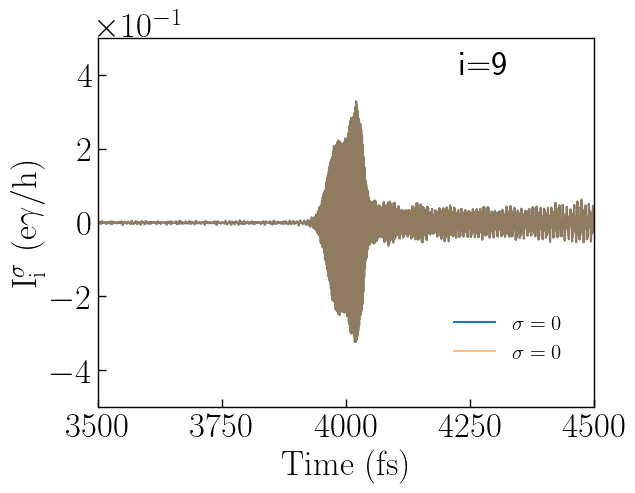

PyObject <matplotlib.legend.Legend object at 0x7f409ab3c5b0>

In [1472]:
#### Layer 1

fig,axs =  plt.subplots(1,1)
site = 9
sites = range(1,3)
# data["ts_bc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
# data["bcc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
for i in site 
    axs.plot(data["ts_bc1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"], data["bcc1_ta1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][:,i],label= raw"$\mathrm{\sigma=0}$")#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(data["ts_bc1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.1"], data["bcc1_ta1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.1"][:,i+1],label= raw"$\mathrm{\sigma=0}$")
    axs.plot(data["ts_bc2_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"], data["bcc2_ta1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][:,i],label= raw"$\mathrm{\sigma=0}$",alpha=0.5)
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscx1_ta1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=x}$")
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscy1_ta1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=y}$",ls=":")
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscz1_ta1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=z}$",ls=":")
    # axs.plot(ts_bc1, bscx1_ta1[:,i],label= raw"$\mathrm{\sigma=x}$")
    # axs.plot(ts_bc1, bscy1_ta1[:,i],label= raw"$\mathrm{\sigma=y}$")
    # axs.plot(ts_bc1, bscz1_ta1[:,i],label= raw"$\mathrm{\sigma=z}$")
end

#axs.text(0.0,-0.1,"i=$(site)" ,fontsize=fs,color="black")
#axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_ylabel(raw"$\mathrm{I^{\sigma}_i\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([0,3500])
#axs.set_ylim(-1e-5,1e-5)

axs.set_ylim(-5e-1,5e-1)

axs.set_xlim([3500,4500])

axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

### Local current with filter

In [165]:
# data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"]
# data["bcc1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"]

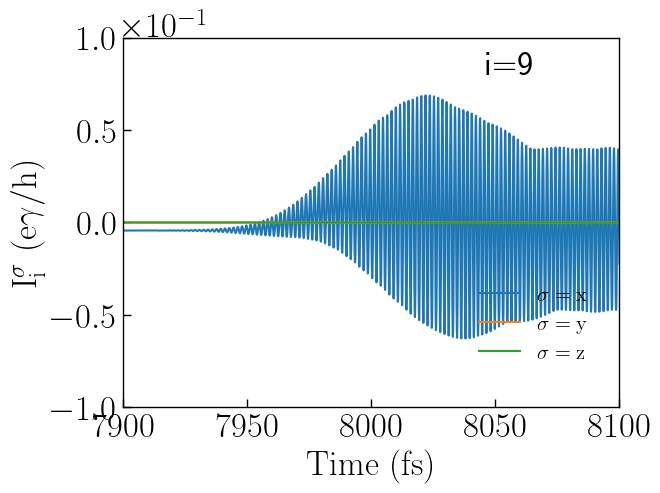

PyObject <matplotlib.legend.Legend object at 0x7fba4749a700>

In [1043]:
fig,axs =  plt.subplots(1,1)
site = 2
sites = range(1,3)

site = 9
sites = range(1,3)




t0=1#10000
tp=2000
tf=150000
σ_freq = 25*6  # Width of the Gaussian filter in frequency domain
#gaussian_filter = exp.(-(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))
gaussian_filter = exp.(-(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))


# Apply the Gaussian filter
# data["ts_bc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
# data["bcc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
for i in site 
    #axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf], data["bcc1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i],label= raw"$\mathrm{\sigma=0}$")
    axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf], data["bscx1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,i],label= raw"$\mathrm{\sigma=x}$")
    axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf], data["bscy1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,i],label= raw"$\mathrm{\sigma=y}$")
    axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf], data["bscz1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,i],label= raw"$\mathrm{\sigma=z}$")
    #axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf], data["bcc1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i+1],label= raw"$\mathrm{\sigma=0}$")

    #axs.plot(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf], data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i],label= raw"$\mathrm{\sigma=0}$")
    #filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
    #axs.plot(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"], filtered_signal,label= raw"$\mathrm{\sigma=0}$",alpha=0.5)#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscx1_ta1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=x}$")
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscy1_ta1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=y}$",ls=":")
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscz1_ta1_test_ns:U_0 .4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=z}$",ls=":")
    # axs.plot(ts_bc1, bscx1_ta1[:,i],label= raw"$\mathrm{\sigma=x}$")
    # axs.plot(ts_bc1, bscy1_ta1[:,i],label= raw"$\mathrm{\sigma=y}$")
    # axs.plot(ts_bc1, bscz1_ta1[:,i],label= raw"$\mathrm{\sigma=z}$")
end

#axs.text(0.0,-0.1,"i=$(site)" ,fontsize=fs,color="black")
axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_ylabel(raw"$\mathrm{I^{\sigma}_i\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([0,3500])
axs.set_ylim(-1e-1,1e-1)

#axs.set_ylim(-5e-1,5e-1)

axs.set_xlim([7900,8100])

axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))


### FFT signal

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


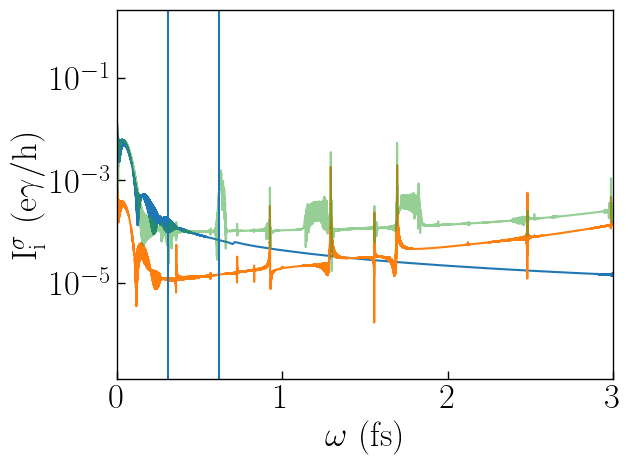

PyObject <matplotlib.lines.Line2D object at 0x7fba64b34b50>

In [663]:
#### Layer 1

fig,axs =  plt.subplots(1,1)
site = 3
sites = range(1,3)



t0=1#10000
tp=2000
tf=40000
σ_freq = 25*6  # Width of the Gaussian filter in frequency domain
#gaussian_filter = exp.(-(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))

# Apply the Gaussian filter
# data["ts_bc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
# data["bcc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
for i in site 




    t0=10000#10000
    #tp=2000
    tf=150000
    #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
    ft  = fftshift(abs.(fft(data["bcc1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i])))
    freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))*2pi/0.1#*1000
    ft_norm = abs.(ft) ./maximum(abs.(ft))
    axs.plot(freqs,ft_norm)
    #axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"], data["bcc1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,i],label= raw"$\mathrm{\sigma=0}$")



    ft  = fftshift(abs.(fft(data["bcc1_ta1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,i])))
    freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
    ft_norm = abs.(ft) ./maximum(abs.(ft))
    axs.plot(freqs,ft_norm)

    ft  = fftshift(abs.(fft(data["bcc1_ta1_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf,i])))
    freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
    ft_norm = abs.(ft) ./maximum(abs.(ft))
    axs.plot(freqs,ft_norm,alpha=0.5)

    #     ft  = fftshift(abs.(fft(data["bcc1_ta1_res_U_0.2+Omega_3.65+zs_0.1+js_0.05"][t0:tf,i])))
    # freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.2+Omega_3.65+zs_0.1+js_0.05"][t0:tf])))*2pi/0.1#*1000
    # ft_norm = abs.(ft) ./maximum(abs.(ft))
    # axs.plot(freqs,ft_norm,alpha=0.5)

    
################################   
    # t0=18000#10000
    # #tp=2000
    # tf=24000
    # #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
    # ft  = fftshift(abs.(fft(data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i])))
    # freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))*2pi/0.1#*1000
    # ft_norm = abs.(ft) ./maximum(abs.(ft))
    # axs.plot(freqs,ft_norm)
    #axs.plot(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"], data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,i],label= raw"$\mathrm{\sigma=0}$")
################################   



################################   
    # t0=18000#10000
    # #tp=2000
    # tf=24000
    # #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
    # ft  = fftshift(abs.(fft(data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,i])))
    # freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
    # ft_norm = abs.(ft) ./maximum(abs.(ft))
    # axs.plot(freqs,ft_norm)
################################      
   




    # t0=18000#10000
    # #tp=2000
    # tf=40000
    # #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
    # ft  = fftshift(abs.(fft(data["bcc1_ta1_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf,i])))
    # freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"][t0:tf])))*2pi/0.1#*1000
    # ft_norm = abs.(ft) ./maximum(abs.(ft))
    # axs.plot(freqs,ft_norm)
    
    # t0=18000#10000
    # #tp=2000
    # tf=24000

################################    
    # t0=1#10000
    # tp=2000
    # tf=40000
    # σ_freq = 25*10  # Width of the Gaussian filter in frequency domain
    # gaussian_filter = exp.(-(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))
    # filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
    # ft  = fftshift(abs.(fft(filtered_signal)))
    # freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))*2pi/0.1#*1000
    # ft_norm = abs.(ft) ./maximum(abs.(ft))
    # axs.plot(freqs,ft_norm,alpha=0.5)
################################



    # t0=1#10000
    # tp=2000
    # tf=40000
    # σ_freq = 25*8  # Width of the Gaussian filter in frequency domain
    # gaussian_filter = exp.(-(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))
    # filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf,i].* gaussian_filter
    # ft  = fftshift(abs.(fft(filtered_signal)))
    # freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
    # ft_norm = abs.(ft) ./maximum(abs.(ft))
    # axs.plot(freqs,ft_norm,alpha=0.5)



    
    
    #axs.plot(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"], filtered_signal,label= raw"$\mathrm{\sigma=0}$",alpha=0.5)#,alpha =1-0.2*i ) ### Charge bound current
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscx1_ta1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=x}$")
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscy1_ta1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=y}$",ls=":")
    #axs.plot(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"], data["bscz1_ta1_test_ns:U_0 .4+Omega_3.65+zs_0.1+js_0.1"][:,i],label= raw"$\mathrm{\sigma=z}$",ls=":")
    # axs.plot(ts_bc1, bscx1_ta1[:,i],label= raw"$\mathrm{\sigma=x}$")
    # axs.plot(ts_bc1, bscy1_ta1[:,i],label= raw"$\mathrm{\sigma=y}$")
    # axs.plot(ts_bc1, bscz1_ta1[:,i],label= raw"$\mathrm{\sigma=z}$")
end

#axs.text(0.0,-0.1,"i=$(site)" ,fontsize=fs,color="black")
#axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_ylabel(raw"$\mathrm{I^{\sigma}_i\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{\omega\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
axs.set_xlim([0,3])
#axs.set_ylim(-1e-5,1e-5)

#axs.set_ylim(0,1e-2)

axs.set_yscale("log")
#axs.set_xlim([1900,2100])

#axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

axs.axvline(3.65,color="red")



axs.axvline([0.31])
axs.axvline([0.31*2])
# axs.axvline([0.31*3])
# axs.axvline([0.31*4])

# axs.axvline(2*3.65,color="red")

# axs.axvline(3*3.65,color="red")

# axs.axvline(4*3.65,color="red")


# axs.axvline(5*3.65,color="red")


In [196]:
using FFTW

### Total current 


In [427]:
#data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf], data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i]
# U0s = [0.0,0.4,1.0]#0.0:0.2:1.0
# ws = 3.65#[2.43,3.04,3.65,4.56,6.08]#[1.6,2.4,3.6]
# zs= 0.1#[0.1,0.2,0.3]#0.1#[0.0,0.02]
# js= [0.1,0.2,0.3]#[0.0,0.02]


U0s = [0.0,0.2]#0.0:0.2:1.0
ws = 3.65#[2.43,3.04,3.65,4.56,6.08]#[1.6,2.4,3.6]
zs= 0.1#[0.1,0.2,0.3]#0.1#[0.0,0.02]
js= [0.0,0.02]#[0.0,0.02]

#test:U_1.0+Omega_1.2+zs_0.01
# Loop through the names and load data
for i1 in 1:length(U0s), i2 in 1:length(ws) ,i3 in 1:length(zs), i4 in 1:length(js)
    #println(i1, i2, i3)
    #println(U0s[i1],ws[i2],zs[i3])
    name = "res_mt_U_$(round(U0s[i1], digits=2))+Omega_$(round(ws[i2], digits=2))+zs_$(round(zs[i3], digits=2))+js_$(round(js[i4], digits=2))"
    println(name)
    data["tbcc_t_$name"] = zeros(Float64,length(data["bcc1_ta1_$name"][:,1]))
    for i in range(1,nx-1)
        data["tbcc_t_$name"] +=  data["bcc1_ta1_$name"][:,i] + data["bcc2_ta1_$name"][:,i]
    end
end
    

res_U_0.0+Omega_3.65+zs_0.1+js_0.0
res_U_0.0+Omega_3.65+zs_0.1+js_0.02
res_U_0.0+Omega_3.65+zs_0.1+js_0.05
res_U_0.2+Omega_3.65+zs_0.1+js_0.0
res_U_0.2+Omega_3.65+zs_0.1+js_0.02
res_U_0.2+Omega_3.65+zs_0.1+js_0.05


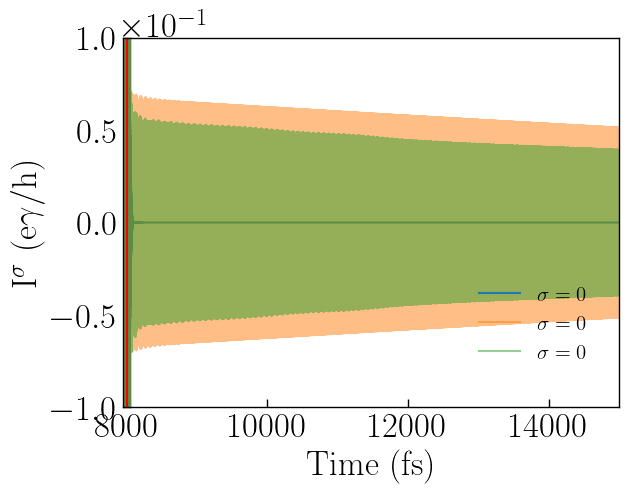

(7950.0, 15000.0)

In [537]:
fig,axs =  plt.subplots(1,1)
site = 2
sites = range(1,3)

site = 9
sites = range(1,3)




t0=1#10000
tp=8000
tf=150000
σ_freq = 25*6  # Width of the Gaussian filter in frequency domain
gaussian_filter = exp.(-(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf].-tp).^2 / (σ_freq^2))


# Apply the Gaussian filter
# data["ts_bc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
# data["bcc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]


axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf],data["tbcc_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf],label= raw"$\mathrm{\sigma=0}$")
axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf],data["tbcc_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf],label= raw"$\mathrm{\sigma=0}$",alpha=0.5)
axs.plot(data["ts_bc1_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf],data["tbcc_t_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf],label= raw"$\mathrm{\sigma=0}$",alpha=0.5)


# filtered_signal = data["tbcc_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf].* gaussian_filter
# axs.plot(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf], filtered_signal,label= raw"$\mathrm{\sigma=0}$",alpha=0.5)#,alpha =1-0.2*i ) ### Charge bound current





# axs.plot(data["ts_bc1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf],data["tbcc_t_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf],label= raw"$\mathrm{\sigma=0}$")

# filtered_signal = data["tbcc_t_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf].* gaussian_filter
# axs.plot(data["ts_bc1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf], filtered_signal,label= raw"$\mathrm{\sigma=0}$",alpha=0.5)#,alpha =1-0.2*i ) ### Charge bound current


#axs.text(0.0,-0.1,"i=$(site)" ,fontsize=fs,color="black")
axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_ylabel(raw"$\mathrm{I^{\sigma}\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([0,3500])
axs.set_ylim(-1e-1,1e-1)

axs.axvline([3000],color="red")
axs.axvline([3500],color="red")
#axs.axvline([4000],color="red")


axs.axvline([8000],color="red")
#axs.set_ylim(-1e-6,1e-6)
#axs.set_xlim([1900,2100])
#axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#axs.set_xlim([3800,6000])
axs.set_xlim([7950,15000])
#axs.set_xlim([1000,8000])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


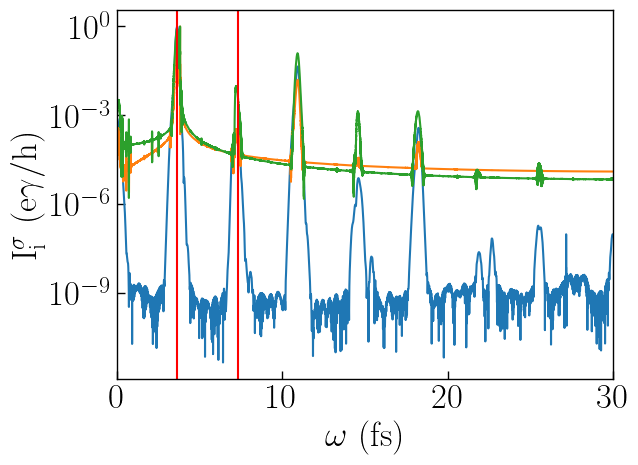

(0.0, 30.0)

In [814]:
#### Layer 1

fig,axs =  plt.subplots(1,1)
site = 2
sites = range(1,3)



# t0=1#10000
# tp=2000
# tf=40000
# σ_freq = 25*6  # Width of the Gaussian filter in frequency domain
# gaussian_filter = exp.(-(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))



# t0=1#10000
# tp=2000
# tf=40000
# σ_freq = 25*6  # Width of the Gaussian filter in frequency domain
# gaussian_filter = exp.(-(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))


# Apply the Gaussian filter
# data["ts_bc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
# data["bcc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]

# axs.plot(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"],data["tbcc_t_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"],label= raw"$\mathrm{\sigma=0}$")

# filtered_signal = data["tbcc_t_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"].* gaussian_filter
# axs.plot(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"], filtered_signal,label= raw"$\mathrm{\sigma=0}$",alpha=0.5)#,alpha =1-0.2*i ) ### Charge bound current


# Apply the Gaussian filter
# data["ts_bc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]
# data["bcc1_ta1xtest_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"]

# t0=18000#10000
# #tp=2000
# tf=28000


t0=10000#19000#10000
#tp=2000
tf=150000#40000
#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["tbcc_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))
freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))*2pi/0.1#*1000
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm)



# t0=70000#19000#10000
# #tp=2000
# tf=90000#40000
#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["tbcc_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))
freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm)




# t0=75000#19000#10000
# #tp=2000
# tf=85000#40000
#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["tbcc_t_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))
freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm)

# t0=18000#19000#10000
# #tp=2000
# tf=22000#40000
# #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
# ft  = fftshift(abs.(fft(data["tbcc_t_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)
    #axs.plot(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"], data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][:,i],label= raw"$\mathrm{\sigma=0}$")





# ft  = fftshift(abs.(fft(data["tbcc_t_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)

# t0=30000#19000#10000
# #tp=2000
# tf=80000#40000
# ft  = fftshift(abs.(fft(data["tbcc_t_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)





# t0=38000#19000#10000
# #tp=2000
# tf=55000#40000
# ft  = fftshift(abs.(fft(data["tbcc_t_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)

# # t0=18000#19000#10000
# # #tp=2000
# # tf=28000#40000
# ft  = fftshift(abs.(fft(data["tbcc_t_test_ns_mt:U_0.4+Omega_3.65+zs_0.1+js_0.05"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns_mt:U_0.4+Omega_3.65+zs_0.1+js_0.05"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)








# t0=18000#19000#10000
# #tp=2000
# # tf=28000#40000
# ft  = fftshift(abs.(fft(data["tbcc_t_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm,alpha=0.5)


#axs.text(0.0,-0.1,"i=$(site)" ,fontsize=fs,color="black")
#axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_ylabel(raw"$\mathrm{I^{\sigma}_i\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{\omega\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([0,35])
#axs.set_ylim(0,0.1e-2)

#axs.set_ylim(-5e-1,5e-1)

axs.set_yscale("log")
#axs.set_xlim([1900,2100])

#axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

axs.axvline(3.65,color="red")
axs.axvline(2*3.65,color="red")
# axs.axvline(3*3.65,color="red")
# axs.axvline(4*3.65,color="red")
# axs.axvline(5*3.65,color="red")
# axs.axvline(6*3.65,color="red")
# axs.axvline(7*3.65,color="red")
# axs.axvline(8*3.65,color="red")


#axs.axvline([0.26/2],color="black")

#axs.axvline([0.13*2],color="black")

#axs.axvline([0.26],color="black")

#axs.axvline([0.26*2],color="black")


#axs.axvline([3.65],color="blue")


# axs.axvline([0.36*2],color="blue")

# axs.axvline([0.13*4])

# axs.axvline([0.13*5])

#axs.axvline([0.36*6],color="blue")


# axs.axvline([0.27])
# axs.axvline([0.32])

# axs.axvline([0.275])

axs.set_xlim([0,30])

In [1426]:
data["chi_nd_t_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"]

80000×1 Matrix{Float64}:
 0.18306377118382539
 0.6338207425497051
 1.138007611122324
 1.5139893256859855
 1.6928229883043162
 1.693495514480238
 1.5747556210902074
 1.4280432290193565
 1.4360036494521653
 1.6137938944365462
 1.6946091883877936
 1.6304755436457135
 1.5201439629233238
 ⋮
 0.07455515944034802
 0.07416868382140235
 0.07368794116078697
 0.07442293558281517
 0.07517168494453794
 0.07542116046443484
 0.07588213772960675
 0.07509061043155534
 0.07427804650428835
 0.0744553629861966
 0.07524686856865798
 0.07535848945344595

## Order parameter

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


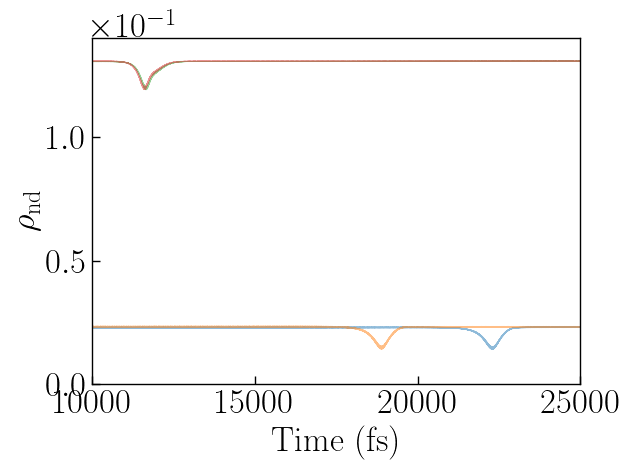

In [187]:


#chi_f
fig,axs = plt.subplots(1,1)
fs=25
#axs.plot(ts,data["chi_f_test:U_0.0+Omega_1.2+zs_0.01"],lw = 0.5)#,label = raw"$\mathrm{I_R}$")
# axs.plot(data["ts_chi_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"],data["chi_nd_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"],lw = 0.5)#
#axs.plot(data["ts_chi_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)
# axs.plot(data["ts_chi_res_U_0.01+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_U_0.01+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)
# axs.plot(data["ts_chi_res_U_0.05+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_U_0.05+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)
########axs.plot(data["ts_chi_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_mt_U_0.1+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)

axs.plot(data["ts_chi_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"],data["chi_nd_t_testA_U_0.0+Omega_3.65+zs_0.0+js_0.02"],lw = 0.5,alpha=0.5)
axs.plot(data["ts_chi_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_mt_U_0.0+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)




axs.plot(data["ts_chi_testA_U_0.2+Omega_3.65+zs_0.0+js_0.02"],data["chi_nd_t_testA_U_0.2+Omega_3.65+zs_0.0+js_0.02"],lw = 0.5,alpha=0.5)
axs.plot(data["ts_chi_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_mt_U_0.2+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)

# axs.plot(data["ts_chi_res_U_0.15+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_U_0.15+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)
# axs.plot(data["ts_chi_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)
#axs.plot(data["ts_chi_res_U_0.4+Omega_3.65+zs_0.1+js_0.02"],data["chi_nd_t_res_U_0.4+Omega_3.65+zs_0.1+js_0.02"],lw = 0.5,alpha=0.5)
#axs.plot(data["ts_chi_res_U_0.2+Omega_3.65+zs_0.1+js_0.05"],data["chi_nd_t_res_U_0.2+Omega_3.65+zs_0.1+js_0.05"],lw = 0.5,alpha=0.5)
#axs.plot(data["ts_chi_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["chi_nd_t_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.2+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.3+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.4+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.5+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.6+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.7+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.8+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.9+Omega_1.2+zs_0.01"],lw = 0.9)#
# axs.plot(data["ts_chi_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["chi_nd_t_test_ns_mt:U_0.4+Omega_3.65+zs_0.1+js_0.05"],lw = 0.9,alpha=0.5)#

# axs.plot(data["ts_chi_test_ns_mt:U_0.0+Omega_3.65+zs_0.1+js_0.05"],data["chi_nd_t_test_ns_mt:U_1.0+Omega_3.65+zs_0.1+js_0.05"],lw = 0.9,alpha=0.5)#

axs.set_ylabel(raw"$\mathrm{\rho_{nd}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
#axs.set_ylim([-1e-1,1e-1])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([200,1500])
#axs.set_xlim([950,1050])
# axs.set_xlim([10000,14000])
axs.set_xlim([10000,25000])
#axs.set_xlim([7900,8200])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
axs.set_ylim([0.0,0.14])
#axs.set_yscale("log")
#axs.axvline(250)
plt.tight_layout()

In [71]:
#data["ts_chi_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"]

In [1259]:
#chi_f
fig,axs = plt.subplots(1,1)
fs=25


#axs.plot(ts,data["chi_f_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.1"],lw = 0.5)#,label = raw"$\mathrm{I_R}$")
#axs.plot(ts,data["chi_f_test:U_0.1+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test_ns:U_0.2+Omega_3.65+zs_0.1+js_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.3+Omega_3.34+zs_0.1"],lw = 0.5)#
axs.plot(ts,data["chi_f_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.5+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test_ns:U_0.6+Omega_3.65+zs_0.1+js_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.7+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test_ns:U_0.8+Omega_3.65+zs_0.1+js_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.9+Omega_3.34+zs_0.1"],lw = 0.9)#
#axs.plot(ts,data["chi_f_test_ns:U_1.0+Omega_3.65+zs_0.1+js_0.1"],lw = 0.9)#

axs.set_ylabel(raw"$\mathrm{\rho_{nd}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
#axs.set_ylim([-1e-1,1e-1])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
axs.set_xlim([200,1500])
#axs.set_xlim([950,1050])
#axs.set_xlim([1900,2100])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
axs.set_ylim([0.1,0.6])
axs.axvline(250)
plt.tight_layout()

LoadError: KeyError: key "chi_f_test_ns:U_0.4+Omega_3.65+zs_0.1+js_0.1" not found

In [ ]:

#chi_f
fig,axs = plt.subplots(1,1)
fs=25
axs.plot(ts,data["chi_f_test:U_0.0+Omega_1.2+zs_0.01"],lw = 1.9)#,label = raw"$\mathrm{I_R}$")
#axs.plot(ts,data["chi_f_test:U_0.1+Omega_1.2+zs_0.01"],lw = 1.5)#
#axs.plot(ts,data["chi_f_test:U_0.2+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.3+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.4+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.5+Omega_1.2+zs_0.01"],lw = 1.5)#
#axs.plot(ts,data["chi_f_test:U_0.6+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.7+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.8+Omega_1.2+zs_0.01"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.9+Omega_1.2+zs_0.01"],lw = 0.9)#
axs.plot(ts,data["chi_f_test:U_1.0+Omega_1.2+zs_0.01"],lw = 1.9)#

axs.set_ylabel(raw"$\mathrm{\rho_{nd}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
#axs.set_ylim([-1e-1,1e-1])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([200,1500])
#axs.set_xlim([950,1050])
axs.set_xlim([1900,2100])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
#axs.set_ylim([0.1,0.8])
axs.axvline(250)
plt.tight_layout()

In [1255]:
#chi_f
fig,axs = plt.subplots(1,1)
fs=25
axs.plot(ts,data["chi_f_test:U_0.0+Omega_4.25+zs_0.1"],lw = 0.5)#,label = raw"$\mathrm{I_R}$")
#axs.plot(ts,data["chi_f_test:U_0.1+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.2+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.3+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.4+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.5+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.6+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.7+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.8+Omega_3.34+zs_0.1"],lw = 0.5)#
#axs.plot(ts,data["chi_f_test:U_0.9+Omega_3.34+zs_0.1"],lw = 0.9)#
axs.plot(ts,data["chi_f_test:U_1.0+Omega_4.25+zs_0.1"],lw = 0.9)#

axs.set_ylabel(raw"$\mathrm{\rho_{nd}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
#axs.set_ylim([0.5,1e-1])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([200,1500])
#axs.set_xlim([950,1050])
#axs.set_xlim([1900,2100])
#axs.set_xlim([1900,2600])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
#axs.set_ylim([0.4,2.5])
#axs.set_yscale("log")
axs.axvline(250)
plt.tight_layout()

LoadError: KeyError: key "chi_f_test:U_0.0+Omega_4.25+zs_0.1" not found

In [1050]:
fig,axs =  plt.subplots(1,1)
site = 1 
sites = range(1,Int(n//5))

axs.scatter(range(1,20),cden_ta1[31000,1:2:end,],label= "site=$(site)")#,alpha =1-0.2*i ) ### Charge bound current
axs.scatter(range(1,20),cden_ta1[31000,2:2:end,],label= "site=$(site)")

axs.set_xlim([-0.1,0.1])
#cden_ta1

LoadError: UndefVarError: `cden_ta1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
fig,axs =  plt.subplots(1,1)
axs.scatter(range(1,20),cden_ta1[4000,1:2:end,],label= "site=$(site)")

In [ ]:
# n=2

# dims_Omega1= (2,2)
# zeros(ComplexF64, dims_Omega1 )
#Array{ComplexF64}(undef,dims_Omega1)

## Optical abs

In [743]:
A=1
sigma=25
omega=3.65
tp=8000
A_light(ts) = A*exp.(-(ts.-tp).^2/(2sigma^2)).*sin.(omega*ts)

A_light (generic function with 1 method)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


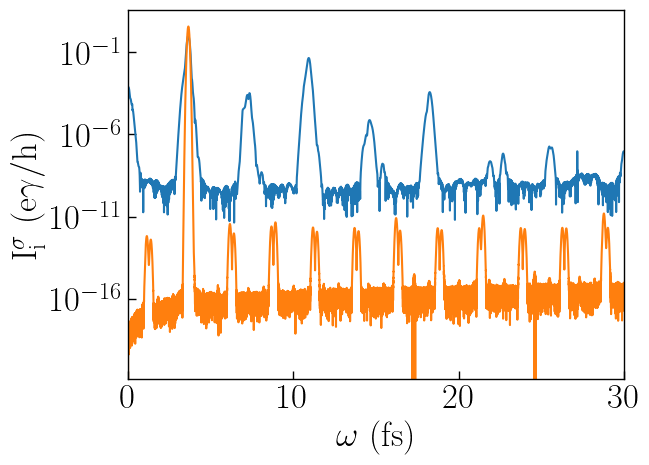

(0.0, 30.0)

In [753]:
#### Layer 1

fig,axs =  plt.subplots(1,1)
site = 2
sites = range(1,3)



# t0=1#10000
# tp=2000
# tf=40000
# σ_freq = 25*6  # Width of the Gaussian filter in frequency domain
# gaussian_filter = exp.(-(data["ts_bc1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf].-tp).^2 / (σ_freq^2))


t0=10000#19000#10000
#tp=2000
tf=150000#40000

freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))*2pi/0.1#*1000

A_t = A_light.(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"])

ft_A  = fftshift(abs.(fft(A_t[t0:tf])))
#    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
ft  = fftshift(abs.(fft(data["tbcc_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf])))
ftA_norm = abs.(ft_A) ./maximum(abs.(ft_A))
ft_norm = abs.(ft) ./maximum(abs.(ft))
axs.plot(freqs,ft_norm)
axs.plot(freqs,ftA_norm.*freqs)
#axs.plot(freqs,c)


# #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
# ft  = fftshift(abs.(fft(data["tbcc_t_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.0+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)

# #    filtered_signal = data["bcc1_ta1_test_ns:U_0.0+Omega_3.65+zs_0.1+js_0.0"][t0:tf,i].* gaussian_filter
# ft  = fftshift(abs.(fft(data["tbcc_t_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))
# freqs  = fftshift(fftfreq(length(data["ts_bc1_res_U_0.2+Omega_3.65+zs_0.1+js_0.02"][t0:tf])))*2pi/0.1#*1000
# ft_norm = abs.(ft) ./maximum(abs.(ft))
# axs.plot(freqs,ft_norm)


axs.set_ylabel(raw"$\mathrm{I^{\sigma}_i\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{\omega\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([0,35])
#axs.set_ylim(0,0.1e-2)

#axs.text(x=0.78, y=0.9, s="i=$(site)",fontsize=fs,ha="center",color="black", transform=axs.transAxes)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))

# axs.axvline(3.65,color="red")
# axs.axvline(2*3.65,color="red")
axs.set_yscale("log")

axs.set_xlim([0,30])

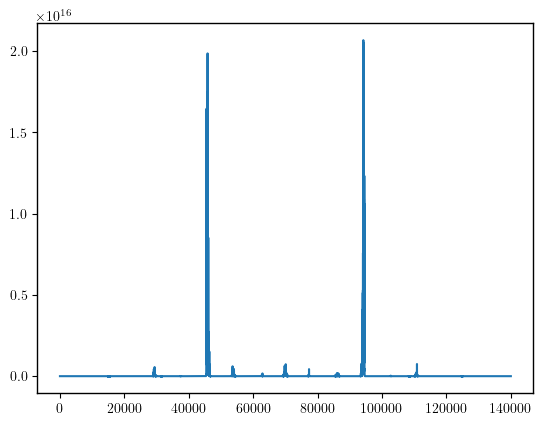

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fba3f7e9670>

In [751]:
# axs.plot(freqs,ft_norm)
# axs.plot(freqs,ftA_norm.*freqs)
c= ft_norm./(ftA_norm)

# Identify elements that are Inf or NaN
invalid_mask = isinf.(c) .| isnan.(c)

# Extract only the invalid values
invalid_values = c[invalid_mask]

plot(c)